# Notebook para generar conjuntos de datos

Este notebook permite generar datasets para el entrenamiento de modelos. Cada seccion emplea diferentes criterios para la creacion de un conjunto de datos.


# Funciones y librerías necesarias
Ejecutar inicialmente esta celda antes que cualquiera de las secciones para poder agregar las librerías y otras dependencias al kernel o interprete en uso.

In [2]:
# librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Descarga del dataset subido a google drive
IMS_dataset_path = 'datos/IMS_bearing_dataset'

if os.path.exists(IMS_dataset_path):
    print("El dataset ya se encuentra descargado.")
else:
    print("Descargando el dataset...")
    try:
        import gdown
    except ImportError:
        !pip install gdown

    # https://drive.google.com/file/d/10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD/view?usp=drive_link
    file_id = "10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD"
    !gdown --id {file_id} -O NASA_IMS_bearing_dataset.zip


    !mkdir -p datos/IMS_bearing_dataset
    print(f"descomprimiendo el daset en {IMS_dataset_path}...")
    !unzip NASA_IMS_bearing_dataset.zip -d {IMS_dataset_path} >> /dev/null
    !rm NASA_IMS_bearing_dataset.zip
    print("Dataset descargado y descomprimido correctamente.")

El dataset ya se encuentra descargado.


In [4]:
def cargar_archivo(ruta, sep='\t'):
  """
    Carga un archivo CSV y asigna nombre a las columnas.

    Esta función lee un archivo CSV desde la ruta proporcionada, asumiendo que
    los valores están separados por tabulaciones ('\t'). Luego, asigna nombres
    genéricos a las columnas del dataset en el formato 'Canal 1', 'Canal 2', ...,
    según la cantidad de columnas que tenga el archivo.

    Args:
        ruta (str): La ruta completa al archivo CSV que se desea cargar.
        sep (str, optional): El separador utilizado en el archivo CSV. Por defecto es '\t'.

    Returns:
        pd.DataFrame: Un DataFrame de pandas con los datos cargados, con nombres
        de columnas asignados como 'Canal 1', 'Canal 2', etc.

    Example:
        >>> cargar_archivo('ruta/al/archivo.csv')
        <DataFrame con las columnas renombradas>
  """
  dataset = pd.read_csv(ruta, sep=sep)
  cantidad_columnas = len(dataset.columns)
  dataset.columns = [f"Canal {i}" for i in range(1, cantidad_columnas + 1)]
  return dataset

# Franjas de salud de Miltos-90

En esta sección se genera un conjunto de datos con los experimentos crudos y con la columna target con los valores de salud propuestos por Miltos-90

# Vida útil de los rodamientos Rexnord

En esta sección se genera un conjunto de datos con los experimentos crudos y con la columna target con los valores de vida útil de los rodamientos Rexnord (100 millones de revoluciones), las mediciones obtenidas pasada la vida útil del rodamiento estará marcada como con falla.

# Datasets con datos agregados 

Este conjunto de datos consiste en aplanar cada archivo de serie de tiempo (correspondiente a una medición de 1 segundos a 20 khz).

Las columnas o características que se calcularán fueron vistas en Condition Monitoring with Vibration Signals: Compressive Sampling and Learning Algorithms for Rotating Machines (Capitulo 3. Análisis en el dominio del tiempo, seccion 2. funciones estadísticas). Los estadísticos son los siguientes:

1. Amplitud máxima (Peak Amplitude)
2. Amplitud media (Mean Amplitude)
3. Amplitud cuadrática media (RMS) (Root Mean Square Amplitude)
4. Amplitud pico a pico (Peak-to-Peak Amplitude)
5. Factor de cresta (Crest Factor, CF)
6. Varianza (Variance)
7. Desviación estándar (Standard Deviation)
8. Error estándar (Standard Error)
9. Cruce por cero (Zero Crossing)
10. Longitud de onda (Wavelength)
11. Amplitud de Willison (Willison Amplitude)
12. Cambio de signo de la pendiente (Slope Sign Change)
13. Factor de impulso (Impulse Factor)
14. Factor de margen (Margin Factor)
15. Factor de forma (Shape Factor)
16. Factor de holgura (Clearance Factor)
17. Asimetría / Sesgo (Skewness)
18. Curtosis (Kurtosis)
19. Cumulantes de orden superior (Higher-Order Cumulants, HOCs)
20. Entropía (Entropy)

In [5]:
import numpy as np
from scipy.stats import skew, kurtosis, entropy

# 1. Amplitud máxima (Peak Amplitude)
def peak_amplitude(x):
    if x.size == 0:
        return 0

    x_max = np.max(x)
    x_min = np.min(x)

    return 0.5 * (x_max - x_min)
    
# 2. Amplitud media (Mean Amplitude)
def mean_amplitude(x):
    return np.mean(x)

# 3. Amplitud cuadrática media (RMS)
def rms_amplitude(x):
    return np.sqrt(np.mean(np.square(x)))
    

# 4. Amplitud pico a pico (Peak-to-Peak Amplitude)
def peak_to_peak_amplitude(x):
    return np.max(x) - np.min(x)

# 5. Factor de cresta (Crest Factor)
def crest_factor(x):
    return peak_amplitude(x) / rms_amplitude(x)

# 6. Varianza
def variance(x):
    return np.var(x)

# 7. Desviación estándar
def standard_deviation(x):
    return np.std(x)

# 8. Error estándar
def standard_error(x):
    return np.std(x) / np.sqrt(len(x))

# 9. Cruce por cero (Zero Crossing)
def zero_crossings(x, threshold=0):
    """
    Calcula el número de cruces por cero de una serie de tiempo.

    Args:
        x (list or numpy.ndarray): La señal de entrada.
        threshold (float): Un umbral para ignorar pequeños cruces cercanos a cero, útiles para señales con ruido.

    Returns:
        int: El número de cruces por cero.
    """
    if len(x) < 2:
        return 0

    crossings = 0
    # Iterar a partir del segundo elemento para comparar con el anterior
    for i in range(1, len(x)):
        x_i = x[i]
        x_i_menos_1 = x[i-1]

        # Condición 1: Cambio de positivo a negativo (x_i-1 > 0 y x_i < 0)
        # Condición 2: Cambio de negativo a positivo (x_i-1 < 0 y x_i > 0)
        # El threshold evita contar cruces que son solo pequeñas variaciones
        # cercanas a cero.
        if (x_i_menos_1 > threshold and x_i < -threshold) or \
           (x_i_menos_1 < -threshold and x_i > threshold):
            crossings += 1
            
    return crossings

# 10. Longitud de onda (Wavelength)
def wavelength(x):
    """
    Calcula la variación total de una serie de tiempo, basada en la suma de las
    diferencias absolutas entre puntos consecutivos.

    Args:
        x (list or numpy.ndarray): La señal de entrada.

    Returns:
        float: La variación total de la señal. Devuelve 0.0 si la señal tiene
               menos de dos puntos.
    """
    if len(x) < 2:
        return 0.0

    # Usamos np.diff para calcular las diferencias entre puntos consecutivos
    diferencias = np.diff(x)
    
    # Calculamos el valor absoluto de cada diferencia
    diferencias_absolutas = np.abs(diferencias)
    
    # Sumamos todas las diferencias absolutas para obtener la variación total
    variacion_total = np.sum(diferencias_absolutas)
    
    return variacion_total

# 11. Amplitud de Willison
def willison_amplitude(x, threshold=0.01):
    return np.sum(np.abs(np.diff(x)) >= threshold)

# 12. Cambio de signo de la pendiente (Slope Sign Change)
def slope_sign_change(x, threshold=0.01):
    """
    Calcula el número de veces que la pendiente de una serie de tiempo cambia de signo.

    Args:
        x (list or numpy.ndarray): La señal de entrada.
        threshold (float): El umbral para ignorar cambios de signo pequeños.

    Returns:
        int: El número de cambios de signo de la pendiente. Devuelve 0 si la
             señal tiene menos de tres puntos.
    """
     # Se necesitan al menos 3 puntos para calcular dos diferencias consecutivas.
    if len(x) < 3:
        return 0

    cambios_de_signo = 0
    # Iterar desde el segundo elemento hasta el penúltimo
    # para tener acceso a x_i-1, x_i y x_i+1
    for i in range(1, len(x) - 1):
        # Calcular las dos diferencias consecutivas
        diff1 = x[i] - x[i-1]
        diff2 = x[i] - x[i+1]
        
        # Calcular el producto de las diferencias
        producto = diff1 * diff2
        
        # Comprobar si el producto es negativo (cambio de signo)
        if producto < 0 and producto >= threshold:
            cambios_de_signo += 1
            
    return cambios_de_signo

# 13. Factor de impulso (Impulse Factor)
def impulse_factor(x):
    return peak_amplitude(x) / np.mean(np.abs(x))

# 14. Factor de margen (Margin Factor)
def margin_factor(x):
    return peak_amplitude(x) / (np.mean(np.sqrt(np.abs(x)))**2)

# 15. Factor de forma (Shape Factor)
def shape_factor(x):
    return rms_amplitude(x) / np.mean(np.abs(x))

# 16. Factor de holgura (Clearance Factor)
def clearance_factor(x):
    return np.max(x) / ((np.mean(np.sqrt(np.abs(x))))**2)

# 17. Asimetría (Skewness)
def skewness(x):
    return skew(x)

# 18. Curtosis (Kurtosis)
def kurt(x):
    return kurtosis(x)

# 19. Cumulantes de orden superior (ejemplo: tercer orden)
def higher_order_cumulant(x, order=3):
    if order == 1:
        return np.mean(x)
    elif order == 2:
        return np.var(x)
    elif order == 3:
        return np.mean((x - np.mean(x))**3)
    elif order == 4:
        return np.mean((x - np.mean(x))**4) - 3*np.var(x)**2
    else:
        raise ValueError("Orden no implementado")

# 20. Entropía
def signal_entropy(x, bins=10):
    # El histograma sólo se usa como discrización para tener una función de densidad de probabilidad
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]
    return entropy(hist)


In [6]:
# Prueba de las funciones estadísticas
# print(f"Pico maximo: {peak_amplitude(serie_a['Canal 1'])}")
# print(f"Amplitud media: {mean_amplitude(serie_a['Canal 1'])}")
# print(f"Amplitud RMS: {rms_amplitude(serie_a['Canal 1'])}")
# print(f"Pico a pico: {peak_to_peak_amplitude(serie_a['Canal 1'])}")
# print(f"Factor de cresta: {crest_factor(serie_a['Canal 1'])}")
# print(f"Varianza: {variance(serie_a['Canal 1'])}")
# print(f"Desviación estándar: {standard_deviation(serie_a['Canal 1'])}")
# print(f"Error estándar: {standard_error(serie_a['Canal 1'])}")
# print(f"Cruce por cero: {zero_crossings(serie_a['Canal 1'])}")
# print(f"Longitud de onda: {wavelength(serie_a['Canal 1'])}")
# print(f"Amplitud de Willison: {willison_amplitude(serie_a['Canal 1'])}")
# print(f"Cambio de signo de la pendiente: {slope_sign_change(serie_a['Canal 1'], threshold=skew(serie_a['Canal 1']))}")  
# print(f"Factor de impulso: {impulse_factor(serie_a['Canal 1'])}")
# print(f"Factor de margen: {margin_factor(serie_a['Canal 1'])}")
# print(f"Factor de forma: {shape_factor(serie_a['Canal 1'])}")
# print(f"Factor de holgura: {clearance_factor(serie_a['Canal 1'])}")
# print(f"Asimetría: {skewness(serie_a['Canal 1'])}")
# print(f"Curtosis: {kurt(serie_a['Canal 1'])}")
# print(f"Cumulante de tercer orden: {higher_order_cumulant(serie_a['Canal 1'], order=1)}")
# print(f"Cumulante de tercer orden: {higher_order_cumulant(serie_a['Canal 1'], order=2)}")
# print(f"Cumulante de tercer orden: {higher_order_cumulant(serie_a['Canal 1'], order=3)}")
# print(f"Cumulante de tercer orden: {higher_order_cumulant(serie_a['Canal 1'], order=4)}")
# print(f"Entropía: {signal_entropy(serie_a['Canal 1'], bins=10)}")   

In [51]:
from tqdm import tqdm  # librería de barra de progreso
import os
import pandas as pd

def generar_estadisticas_agregadas_df(path, show_progress=False, output_file='estadisticas_secuencial.csv'):
    """
    Procesa archivos CSV en la carpeta 'path' de forma secuencial.
    Calcula las funciones estadísticas para cada archivo y canal, y guarda los resultados en un archivo CSV.
    """
    archivos = sorted([f for f in os.listdir(path)])
    resultados = []

    total = len(archivos)
    print(f"Procesando {total} archivos en total...")

    # Si show_progress=True, usamos tqdm
    iterator = tqdm(enumerate(archivos), total=total, desc="Procesando archivos") if show_progress else enumerate(archivos)

    for idx, archivo in iterator:
        ruta_archivo = os.path.join(path, archivo)
        df = cargar_archivo(ruta_archivo)
        for channel in df.columns:
            canal = df[channel].values
            stats = {
                'archivo': archivo,
                'canal': channel,
                'peak_amplitude': peak_amplitude(canal),
                'mean_amplitude': mean_amplitude(canal),
                'rms_amplitude': rms_amplitude(canal),
                'peak_to_peak_amplitude': peak_to_peak_amplitude(canal),
                'crest_factor': crest_factor(canal),
                'variance': variance(canal),
                'standard_deviation': standard_deviation(canal),
                'standard_error': standard_error(canal),
                'zero_crossings': zero_crossings(canal),
                'wavelength': wavelength(canal),
                'willison_amplitude': willison_amplitude(canal),
                'slope_sign_change': slope_sign_change(canal, threshold=skew(canal)),
                'impulse_factor': impulse_factor(canal),
                'margin_factor': margin_factor(canal),
                'shape_factor': shape_factor(canal),
                'clearance_factor': clearance_factor(canal),
                'skewness': skewness(canal),
                'kurtosis': kurt(canal),
                'hoc3': higher_order_cumulant(canal, order=3),
                'hoc4': higher_order_cumulant(canal, order=4),
                'entropy': signal_entropy(canal)
            }
            resultados.append(stats)

    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv(output_file, index=False)
    return df_resultados


In [52]:
# Generación del DataFrame con las estadísticas agregadas para el 3rd_test
df_agregado_3rd_test = generar_estadisticas_agregadas_df(path='datos/IMS_bearing_dataset/3rd_test/4th_test/txt', 
                                                         output_file='datos/datos_generados/dataset_agregado_3rd_test.csv',
                                                         show_progress=True)

Procesando 6324 archivos en total...


Procesando archivos: 100%|██████████| 6324/6324 [10:21<00:00, 10.17it/s]


In [53]:
# Generación del DataFrame con las estadísticas agregadas para el 2nd_test
df_agregado_2nd_test = generar_estadisticas_agregadas_df(path='datos/IMS_bearing_dataset/2nd_test/2nd_test', 
                                                         output_file='datos/datos_generados/dataset_agregado_2nd_test.csv',
                                                         show_progress=True)

Procesando 984 archivos en total...


Procesando archivos: 100%|██████████| 984/984 [01:36<00:00, 10.22it/s]


In [50]:
# Generación del DataFrame con las estadísticas agregadas para el 1st_test
df_agregado_1st_test = generar_estadisticas_agregadas_df(path='datos/IMS_bearing_dataset/1st_test/1st_test/', 
                                                         output_file='datos/datos_generados/dataset_agregado_1st_test.csv',
                                                         show_progress=True)
df_agregado_1st_test


Procesando archivos:   0%|          | 0/2156 [00:00<?, ?it/s]

Procesando archivos: 100%|██████████| 2156/2156 [07:06<00:00,  5.05it/s]


,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,slope_sign_change,impulse_factor,margin_factor,shape_factor,clearance_factor,skewness,kurtosis,hoc3,hoc4,entropy
0,2003.10.22.12.06.24,Canal 1,0.5540,-0.094596,0.124617,1.108,4.445630,0.006581,0.081122,0.000567,...,9783,5.319360,6.092483,1.196537,4.266938,-0.029898,1.069246,-0.000016,0.000046,1.178086
1,2003.10.22.12.06.24,Canal 2,0.6325,-0.093883,0.117496,1.265,5.383175,0.004991,0.070649,0.000494,...,0,6.309054,7.083273,1.171995,7.850394,0.220211,3.065961,0.000078,0.000076,0.936417
2,2003.10.22.12.06.24,Canal 3,0.5165,-0.093812,0.130452,1.033,3.959305,0.008217,0.090648,0.000633,...,8780,4.820468,5.600875,1.217504,3.892961,-0.092175,0.209605,-0.000069,0.000014,1.338470
3,2003.10.22.12.06.24,Canal 4,0.3930,-0.093753,0.121644,0.786,3.230726,0.006008,0.077509,0.000542,...,7062,3.852784,4.403420,1.192545,2.868385,-0.053114,0.292136,-0.000025,0.000011,1.435646
4,2003.10.22.12.06.24,Canal 5,0.4480,-0.090811,0.128888,0.896,3.475883,0.008365,0.091463,0.000639,...,0,4.220501,4.889357,1.214224,4.365497,0.034348,0.405279,0.000026,0.000028,1.476715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17243,2003.11.25.23.39.56,Canal 4,0.6285,-0.117193,0.201575,1.257,3.117945,0.026898,0.164007,0.001146,...,6079,3.871862,4.533794,1.241799,3.628478,-0.011821,0.368081,-0.000052,0.000266,1.699514
17244,2003.11.25.23.39.56,Canal 5,4.9990,0.129027,0.593624,9.998,8.421160,0.335741,0.579432,0.004049,...,0,11.402137,13.758413,1.353986,13.755661,0.067193,5.902241,0.013072,0.665313,0.955781
17245,2003.11.25.23.39.56,Canal 6,3.6745,-0.115776,0.496012,7.349,7.408089,0.232624,0.482311,0.003370,...,0,10.093754,12.339231,1.362531,11.806977,0.026514,4.265379,0.002975,0.230816,1.063524
17246,2003.11.25.23.39.56,Canal 7,0.8970,-0.115532,0.229178,1.794,3.913980,0.039175,0.197927,0.001383,...,5666,4.948660,5.867201,1.264355,4.997260,-0.018425,0.625903,-0.000143,0.000961,1.540983


### Asignación de target en 1st_test (salud)

In [9]:
# df_agregado_1st_test[df_agregado_1st_test['canal'] == 'Canal 1']
mask =        (df_agregado_1st_test['archivo'] >= '2003.10.22.12.06.24') # Inicio 
mask = mask & (df_agregado_1st_test['archivo'] <= '2003.10.22.12.09.13') # Fin
mask = mask & (df_agregado_1st_test['canal'] == 'Canal 1') 
df_agregado_1st_test.loc[mask, 'salud'] = 'saludable'

In [ ]:
def asignar_target(df, canal, inicio, fin, target, target_value):
    """
    Asigna un valor de salud/target (en terminos de rodamientos) a la columna [canal] de un
    DataFrame para los archivos cuyo nombre esté dentro del rango especificado por 'inicio' y 'fin'.
    La funcion modifica el DataFrame en su lugar.

    Parámetros:
    df (pd.DataFrame): DataFrame que contiene una columna 'archivo'.
    canal (str): Nombre de la columna del canal a modificar (e.g., 'canal 1').
    inicio (str): Nombre de archivo inicial del rango (inclusive).
    fin (str): Nombre de archivo final del rango (inclusive).
    target (str): Valor de target a asignar. 

    Retorna:
    None: El DataFrame se modifica en su lugar.
    """
    mask =        (df['archivo'] >= inicio)  
    mask = mask & (df['archivo'] <= fin) 
    mask = mask & (df['canal'] == canal) 
    df.loc[mask, target] = target_value

In [ ]:
# Asinación de valores de salud al rodamiento 1 (canales 1 y 2) del 1st_test

# Bearing 1
#   Early:              2003.10.22.12.06.24 - 2003.10.23.09.14.13
#   Suspect:            2003.10.23.09.24.13 - 2003.11.08.12.11.44
#   Normal:             2003.11.08.12.21.44 - 2003.11.19.21.06.07
#   Suspect:            2003.11.19.21.16.07 - 2003.11.24.20.47.32
#   Imminent failure:   2003.11.24.20.57.32 - 2003.11.25.23.39.56

asignar_target(df_agregado_1st_test, 'Canal 1', '2003.10.22.12.06.24', '2003.10.23.09.14.13', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 1', '2003.10.23.09.24.13', '2003.11.08.12.11.44', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 1', '2003.11.08.12.21.44', '2003.11.19.21.06.07', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 1', '2003.11.19.21.16.07', '2003.11.24.20.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 1', '2003.11.24.20.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inminent failure')

asignar_target(df_agregado_1st_test, 'Canal 2', '2003.10.22.12.06.24', '2003.10.23.09.14.13', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 2', '2003.10.23.09.24.13', '2003.11.08.12.11.44', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 2', '2003.11.08.12.21.44', '2003.11.19.21.06.07', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 2', '2003.11.19.21.16.07', '2003.11.24.20.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 2', '2003.11.24.20.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inminent failure')

In [ ]:
# Asinación de valores de salud al rodamiento 2 (canales 3 y 4) del 1st_test

# Bearing 2
#   Early:              2003.10.22.12.06.24 - 2003.11.01.21.41.44
#   Normal:             2003.11.01.21.51.44 - 2003.11.24.01.01.24
#   Suspect:            2003.11.24.01.11.24 - 2003.11.25.10.47.32
#   Imminent failure:   2003.11.25.10.57.32 - 2003.11.25.23.39.56

asignar_target(df_agregado_1st_test, 'Canal 3', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 3', '2003.11.01.21.51.44', '2003.11.24.01.01.24', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 3', '2003.11.24.01.11.24', '2003.11.25.10.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 3', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Imminent failure')

asignar_target(df_agregado_1st_test, 'Canal 4', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 4', '2003.11.01.21.51.44', '2003.11.24.01.01.24', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 4', '2003.11.24.01.11.24', '2003.11.25.10.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 4', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Imminent failure')

In [ ]:
# Asinación de valores de salud al rodamiento 3 (canales 5 y 6) del 1st_test

# Bearing 3
#   Early:              2003.10.22.12.06.24 - 2003.11.01.21.41.44
#   Normal:             2003.11.01.21.51.44 - 2003.11.22.09.16.56
#   Suspect:            2003.11.22.09.26.56 - 2003.11.25.10.47.32
#   Inner race failure: 2003.11.25.10.57.32 - 2003.11.25.23.39.56

asignar_target(df_agregado_1st_test, 'Canal 5', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 5', '2003.11.01.21.51.44', '2003.11.22.09.16.56', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 5', '2003.11.22.09.26.56', '2003.11.25.10.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 5', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inner race failure')

asignar_target(df_agregado_1st_test, 'Canal 6', '2003.10.22.12.06.24', '2003.11.01.21.41.44', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 6', '2003.11.01.21.51.44', '2003.11.22.09.16.56', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 6', '2003.11.22.09.26.56', '2003.11.25.10.47.32', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 6', '2003.11.25.10.57.32', '2003.11.25.23.39.56', 'salud_miltos', 'Inner race failure')


In [ ]:
# Asinación de valores de salud al rodamiento 4 (canales 7 y 8) del 1st_test

# Bearing 4
#   Early:                      2003.10.22.12.06.24 - 2003.10.29.21.39.46
#   Normal:                     2003.10.29.21.49.46 - 2003.11.15.05.08.46
#   Suspect:                    2003.11.15.05.18.46 - 2003.11.18.19.12.30
#   Rolling element failure:    2003.11.19.09.06.09 - 2003.11.22.17.36.56
#   Stage 2 failure:            2003.11.22.17.46.56 - 2003.11.25.23.39.56

asignar_target(df_agregado_1st_test, 'Canal 7', '2003.10.22.12.06.24', '2003.10.29.21.39.46', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 7', '2003.10.29.21.49.46', '2003.11.15.05.08.46', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 7', '2003.11.15.05.18.46', '2003.11.18.19.12.30', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 7', '2003.11.19.09.06.09', '2003.11.22.17.36.56', 'salud_miltos', 'Rolling element failure')
asignar_target(df_agregado_1st_test, 'Canal 7', '2003.11.22.17.46.56', '2003.11.25.23.39.56', 'salud_miltos', 'Stage 2 failure')

asignar_target(df_agregado_1st_test, 'Canal 8', '2003.10.22.12.06.24', '2003.10.29.21.39.46', 'salud_miltos', 'Early')
asignar_target(df_agregado_1st_test, 'Canal 8', '2003.10.29.21.49.46', '2003.11.15.05.08.46', 'salud_miltos', 'Normal')
asignar_target(df_agregado_1st_test, 'Canal 8', '2003.11.15.05.18.46', '2003.11.18.19.12.30', 'salud_miltos', 'Suspect')
asignar_target(df_agregado_1st_test, 'Canal 8', '2003.11.19.09.06.09', '2003.11.22.17.36.56', 'salud_miltos', 'Rolling element failure')
asignar_target(df_agregado_1st_test, 'Canal 8', '2003.11.22.17.46.56', '2003.11.25.23.39.56', 'salud_miltos', 'Stage 2 failure')

In [39]:
df_agregado_1st_test


,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,margin_factor,shape_factor,clearance_factor,skewness,kurtosis,hoc3,hoc4,entropy,salud,salud_miltos
0,2003.10.22.12.06.24,Canal 1,0.5540,-0.094596,0.124617,1.108,4.445630,0.006581,0.081122,0.000567,...,6.092483,1.196537,4.266938,-0.029898,1.069246,-0.000016,0.000046,1.178086,saludable,Early
1,2003.10.22.12.06.24,Canal 2,0.6325,-0.093883,0.117496,1.265,5.383175,0.004991,0.070649,0.000494,...,7.083273,1.171995,7.850394,0.220211,3.065961,0.000078,0.000076,0.936417,NaN,Early
2,2003.10.22.12.06.24,Canal 3,0.5165,-0.093812,0.130452,1.033,3.959305,0.008217,0.090648,0.000633,...,5.600875,1.217504,3.892961,-0.092175,0.209605,-0.000069,0.000014,1.338470,NaN,Early
3,2003.10.22.12.06.24,Canal 4,0.3930,-0.093753,0.121644,0.786,3.230726,0.006008,0.077509,0.000542,...,4.403420,1.192545,2.868385,-0.053114,0.292136,-0.000025,0.000011,1.435646,NaN,Early
4,2003.10.22.12.06.24,Canal 5,0.4480,-0.090811,0.128888,0.896,3.475883,0.008365,0.091463,0.000639,...,4.889357,1.214224,4.365497,0.034348,0.405279,0.000026,0.000028,1.476715,NaN,Early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17243,2003.11.25.23.39.56,Canal 4,0.6285,-0.117193,0.201575,1.257,3.117945,0.026898,0.164007,0.001146,...,4.533794,1.241799,3.628478,-0.011821,0.368081,-0.000052,0.000266,1.699514,NaN,Imminent failure
17244,2003.11.25.23.39.56,Canal 5,4.9990,0.129027,0.593624,9.998,8.421160,0.335741,0.579432,0.004049,...,13.758413,1.353986,13.755661,0.067193,5.902241,0.013072,0.665313,0.955781,NaN,Inner race failure
17245,2003.11.25.23.39.56,Canal 6,3.6745,-0.115776,0.496012,7.349,7.408089,0.232624,0.482311,0.003370,...,12.339231,1.362531,11.806977,0.026514,4.265379,0.002975,0.230816,1.063524,NaN,Inner race failure
17246,2003.11.25.23.39.56,Canal 7,0.8970,-0.115532,0.229178,1.794,3.913980,0.039175,0.197927,0.001383,...,5.867201,1.264355,4.997260,-0.018425,0.625903,-0.000143,0.000961,1.540983,NaN,Stage 2 failure


### Asignación de target en 3rd_test (vida útil)

In [56]:
# Asinación de valores de salud 

# En esta ocasion sólo se asignan valores de salud a los canales 1 y 2. 
# Además, sólo se asignan 2 estados de salud: 'Normal' e 'Inminent failure'


asignar_target(df_agregado_3rd_test, 'Canal 1', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'vida_util', 'Normal')
asignar_target(df_agregado_3rd_test, 'Canal 1', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'vida_util', 'Inminent failure')

asignar_target(df_agregado_3rd_test, 'Canal 2', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'vida_util', 'Normal')
asignar_target(df_agregado_3rd_test, 'Canal 2', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'vida_util', 'Inminent failure')

asignar_target(df_agregado_3rd_test, 'Canal 3', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'vida_util', 'Normal')
asignar_target(df_agregado_3rd_test, 'Canal 3', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'vida_util', 'Inminent failure')

asignar_target(df_agregado_3rd_test, 'Canal 4', '2004.03.04.09.27.46', '2004.04.08.02.31.57', 'vida_util', 'Normal')
asignar_target(df_agregado_3rd_test, 'Canal 4', '2004.04.08.02.41.57', '2004.04.18.02.42.55', 'vida_util', 'Inminent failure')


In [57]:
df_agregado_3rd_test

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,impulse_factor,margin_factor,shape_factor,clearance_factor,skewness,kurtosis,hoc3,hoc4,entropy,vida_util
0,2004.03.04.09.27.46,Canal 1,0.5580,-0.004716,0.079770,1.116,6.995122,0.006341,0.079630,0.000556,...,9.054030,10.870867,1.294335,10.656567,0.030942,1.292610,1.562389e-05,5.197341e-05,1.143656,Normal
1,2004.03.04.09.27.46,Canal 2,0.4820,-0.003918,0.096704,0.964,4.984260,0.009336,0.096625,0.000675,...,6.402905,7.666610,1.284625,8.382372,0.151494,0.776298,1.366670e-04,6.766860e-05,1.453733,Normal
2,2004.03.04.09.27.46,Canal 3,0.3355,-0.005150,0.066391,0.671,5.053391,0.004381,0.066191,0.000463,...,6.453056,7.721736,1.276976,8.308634,0.083539,0.592235,2.422613e-05,1.136816e-05,1.445029,Normal
3,2004.03.04.09.27.46,Canal 4,0.2785,-0.004329,0.055493,0.557,5.018651,0.003061,0.055324,0.000387,...,6.406042,7.671468,1.276447,6.996599,0.038759,0.560056,6.563128e-06,5.246653e-06,1.451498,Normal
4,2004.03.04.09.32.46,Canal 1,0.4760,-0.005097,0.078677,0.952,6.050087,0.006164,0.078511,0.000549,...,7.832276,9.404151,1.294573,9.700500,-0.013894,1.157367,-6.723779e-06,4.397439e-05,1.276069,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25291,2004.04.18.02.32.55,Canal 4,0.9250,-0.003470,0.282170,1.850,3.278164,0.079608,0.282149,0.001972,...,4.038848,4.750676,1.232046,4.524698,-0.108534,-0.485781,-2.437822e-03,-3.078597e-03,1.849811,Inminent failure
25292,2004.04.18.02.42.55,Canal 1,0.0035,0.001533,0.001912,0.007,1.830507,0.000001,0.001143,0.000008,...,2.282909,3.279903,1.247146,4.685576,0.436096,1.299783,6.508719e-10,2.216951e-12,0.756613,Inminent failure
25293,2004.04.18.02.42.55,Canal 2,0.0035,0.002441,0.002789,0.007,1.254758,0.000002,0.001351,0.000009,...,1.434104,1.608192,1.142932,3.216384,0.906362,0.330420,2.233432e-09,1.099750e-12,0.730280,Inminent failure
25294,2004.04.18.02.42.55,Canal 3,0.0035,0.003663,0.003966,0.007,0.882561,0.000002,0.001520,0.000011,...,0.955534,1.002583,1.082683,2.005167,-0.135607,-1.826388,-4.762210e-10,-9.749082e-12,0.733937,Inminent failure


### Visualización y análisis

In [ ]:
colores_salud_hex = {
    'Early': '#F6FF99',
    'Normal': '#A7E399',
    'Suspect': '#FAA533',
    'Inminent failure': '#F75270',
    'Inner race failure': '#9A3F3F',
    'Rolling element failure': '#B87C4C',
    'Stage 2 failure': '#C1856D'
}

In [ ]:
def mostrar_grafica(df, canal, estadistica):
    """
    Muestra una gráfica de la estadística seleccionada para un canal específico.

    Args:
        df (pd.DataFrame): DataFrame que contiene las estadísticas calculadas.
        canal (str): Nombre del canal a graficar (e.g., 'Canal 1').
        estadistica (str): Nombre de la estadística a graficar (e.g., 'mean_amplitude').

    Returns:
        None: Muestra una gráfica.
    """
    df_canal = df[df['canal'] == canal]
    plt.figure(figsize=(12, 6))
    plt.plot(df_canal[estadistica].values)
    plt.title(f'{estadistica} - {canal}')
    plt.xlabel('Índice del archivo')
    plt.ylabel(estadistica)
    plt.grid()
    plt.show()

In [44]:
def mostrar_grafica_target(df, canal, estadistica, target_column, colores):
    """
    Muestra una gráfica de la estadística seleccionada para un canal específico,
    coloreando los puntos según los valores de una columna objetivo.

    Args:
        df (pd.DataFrame): DataFrame que contiene las estadísticas calculadas.
        canal (str): Nombre del canal a graficar (e.g., 'Canal 1').
        estadistica (str): Nombre de la estadística a graficar (e.g., 'mean_amplitude').
        target_column (str): Nombre de la columna objetivo para colorear (e.g., 'salud_miltos').
        colores (dict): Diccionario que mapea valores de la columna objetivo a colores hexadecimales.

    Returns:
        None: Muestra una gráfica.
    """
    df_canal = df[df['canal'] == canal]

    plt.figure(figsize=(14, 6))
    indice_inicial = 0 

    for label, grupo in df_canal.groupby(target_column, sort=False):
        indices = range(indice_inicial , indice_inicial + len(grupo.index))
        plt.plot(indices, grupo[estadistica], label=label, color=colores.get(label, 'gray'))
        indice_inicial += len(grupo.index)

    plt.title(f'{estadistica} - {canal}')
    plt.xlabel('Índice del archivo')
    plt.ylabel(estadistica)
    plt.legend(title=target_column)
    plt.grid()
    plt.show()
            

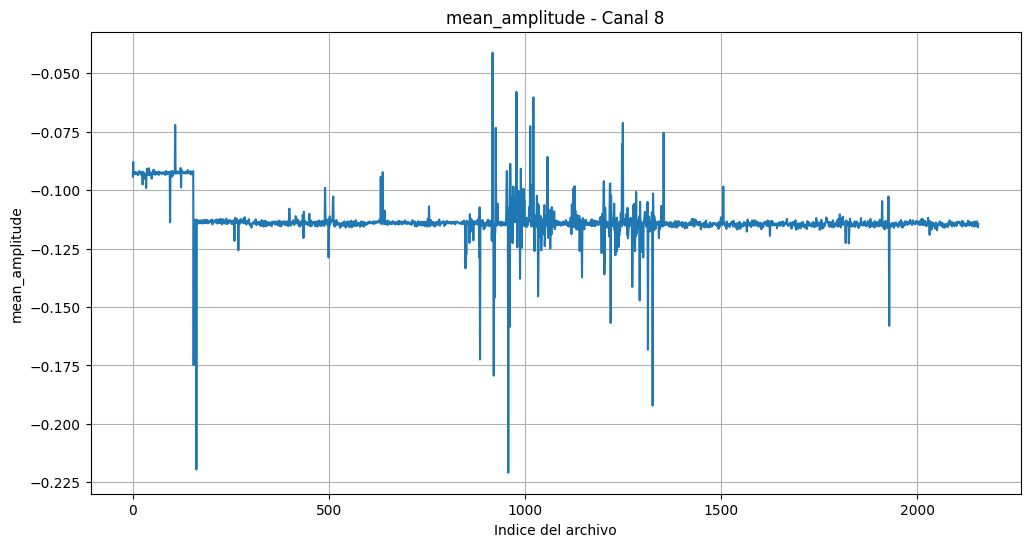

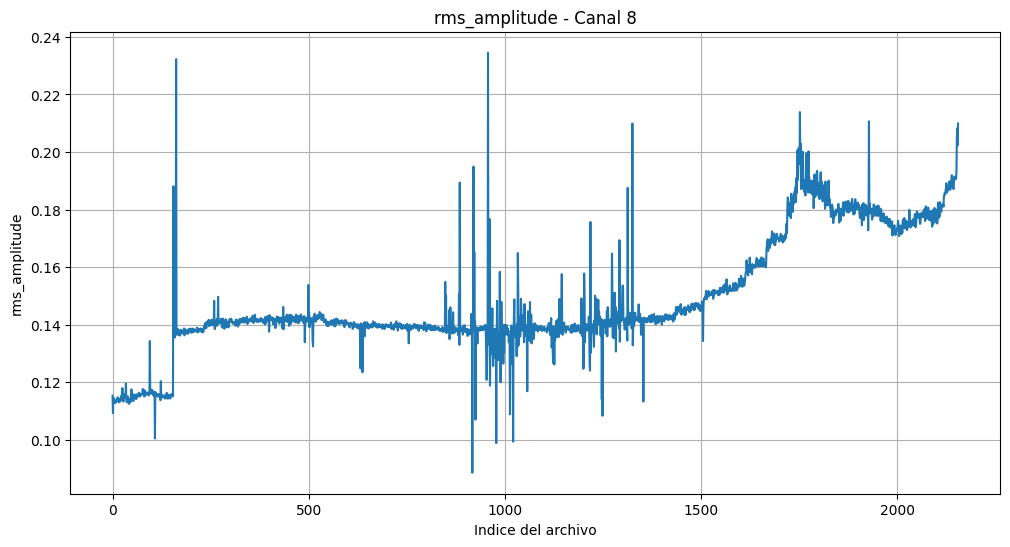

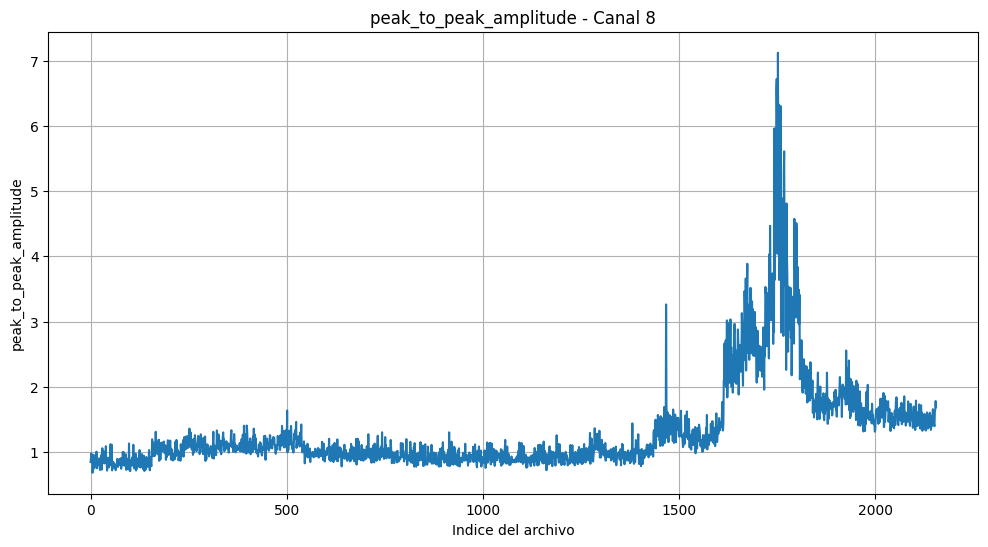

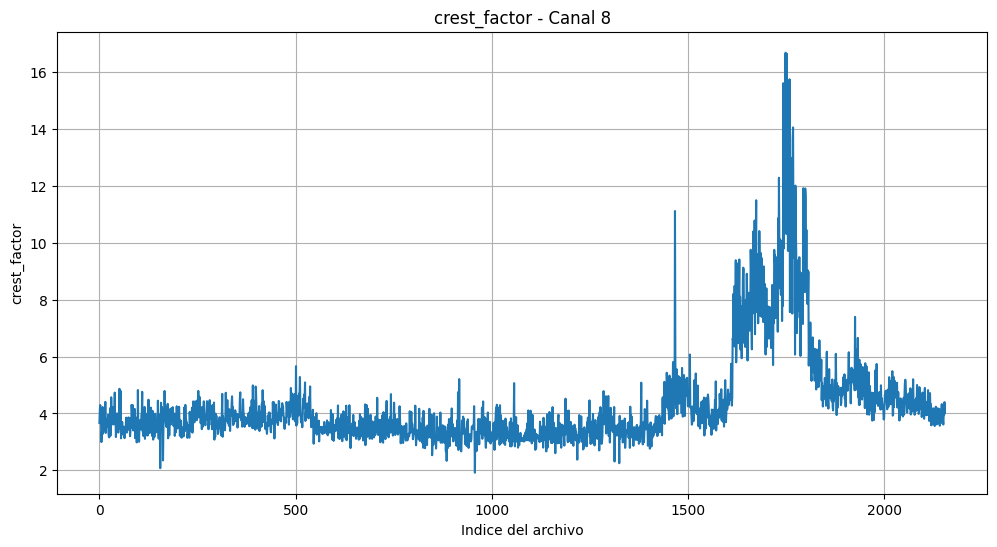

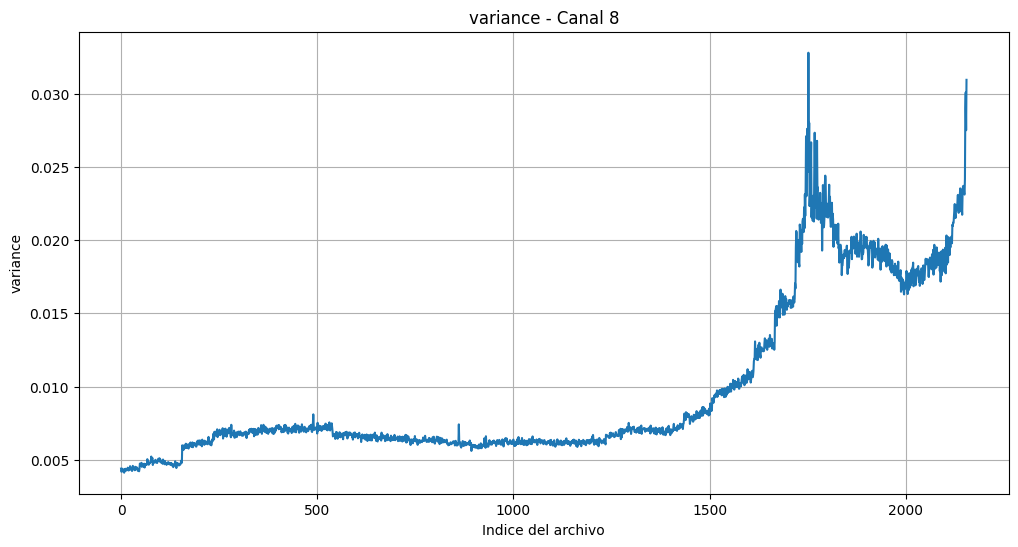

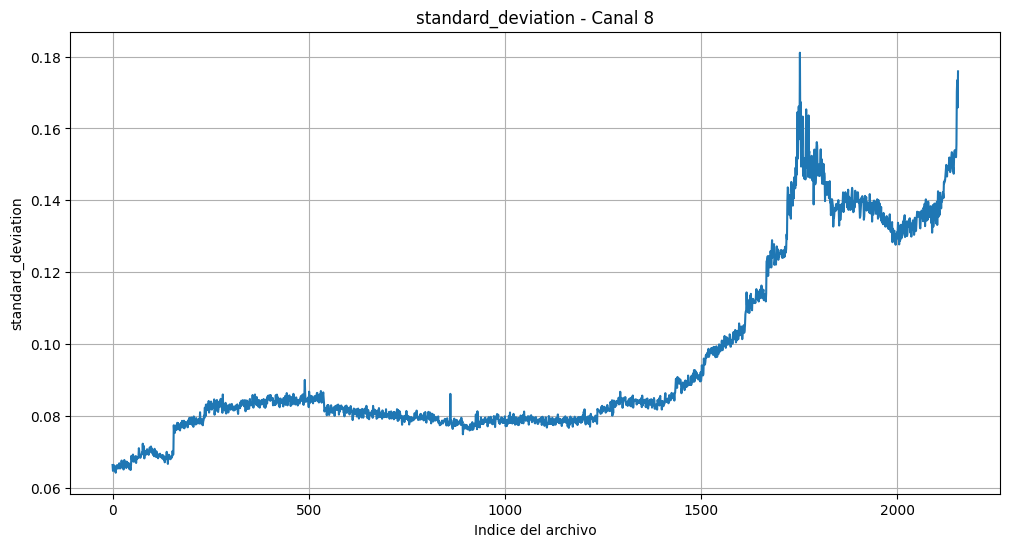

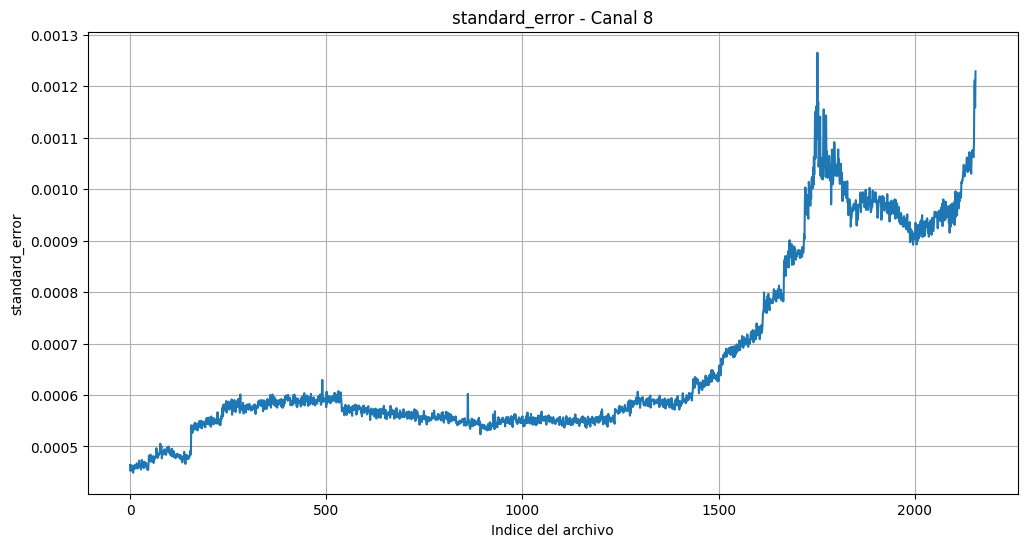

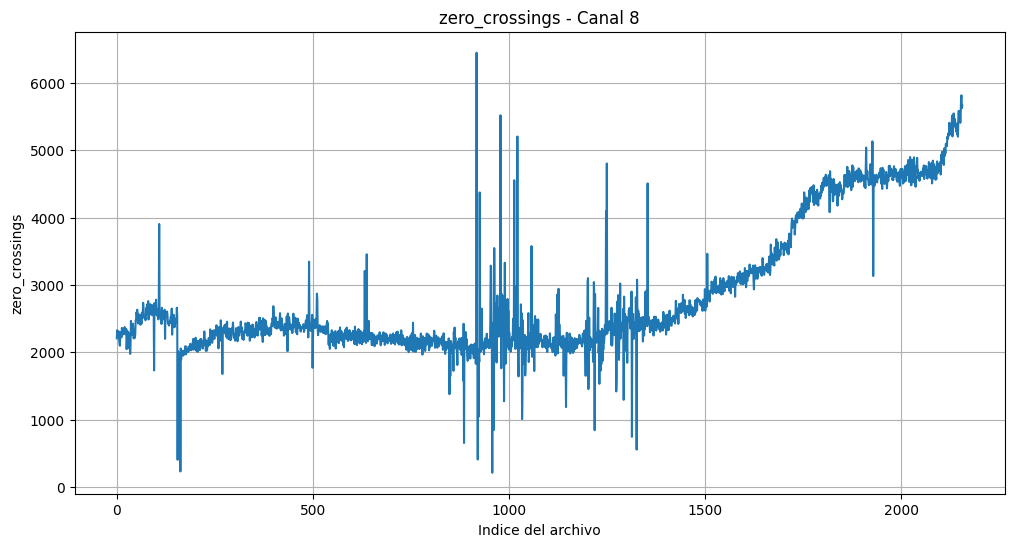

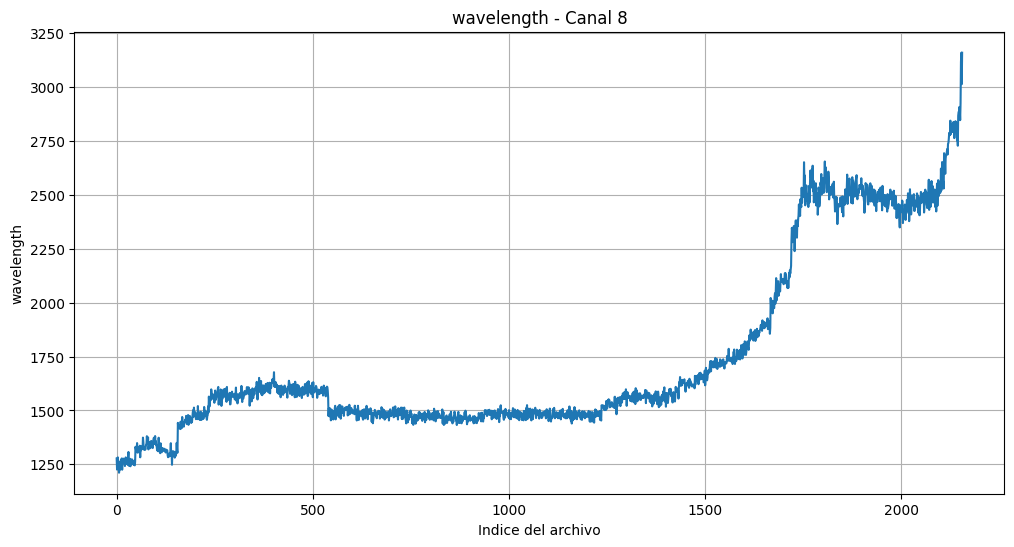

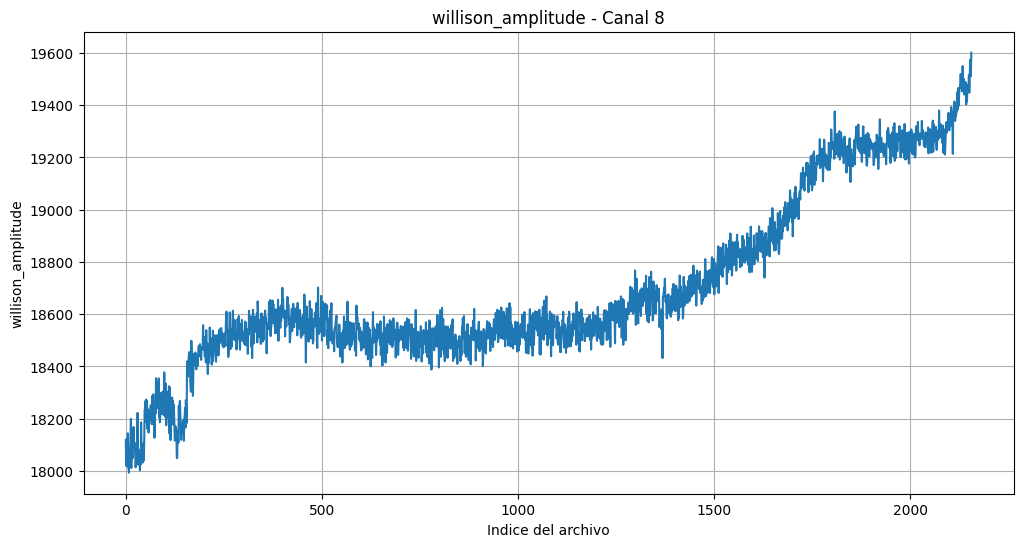

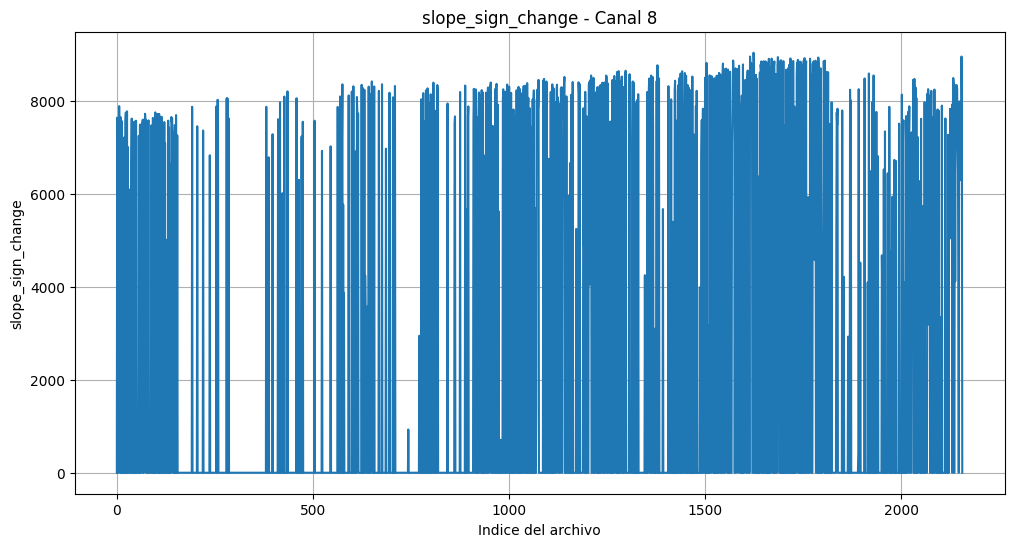

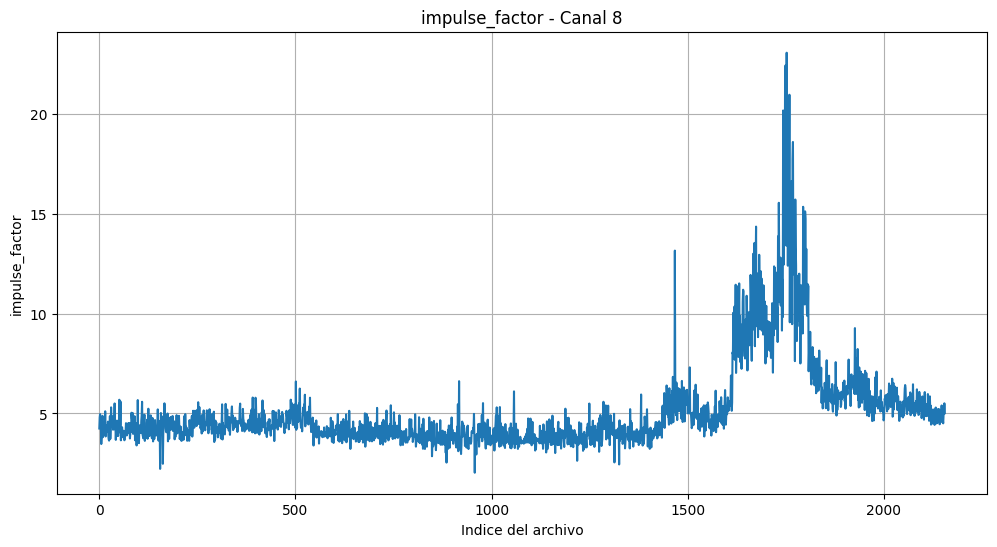

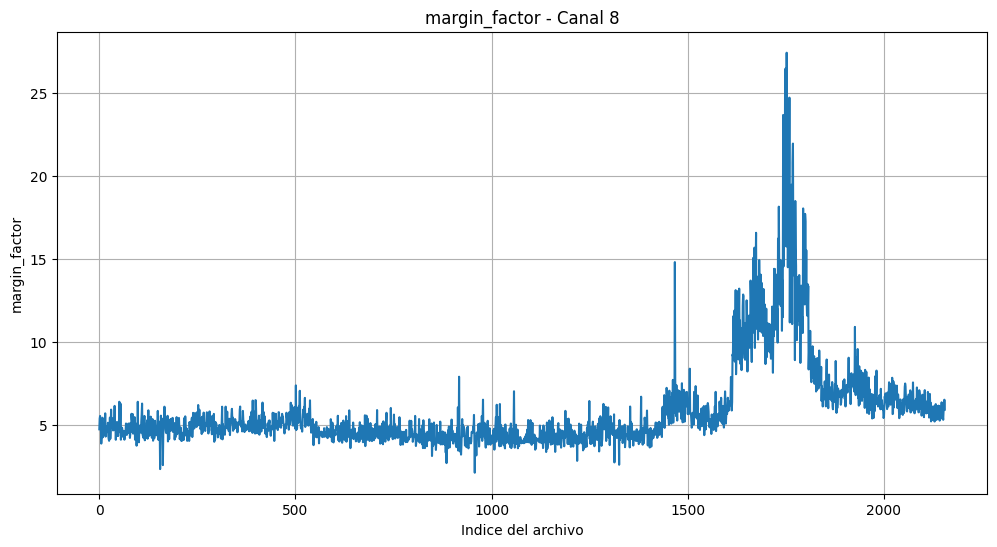

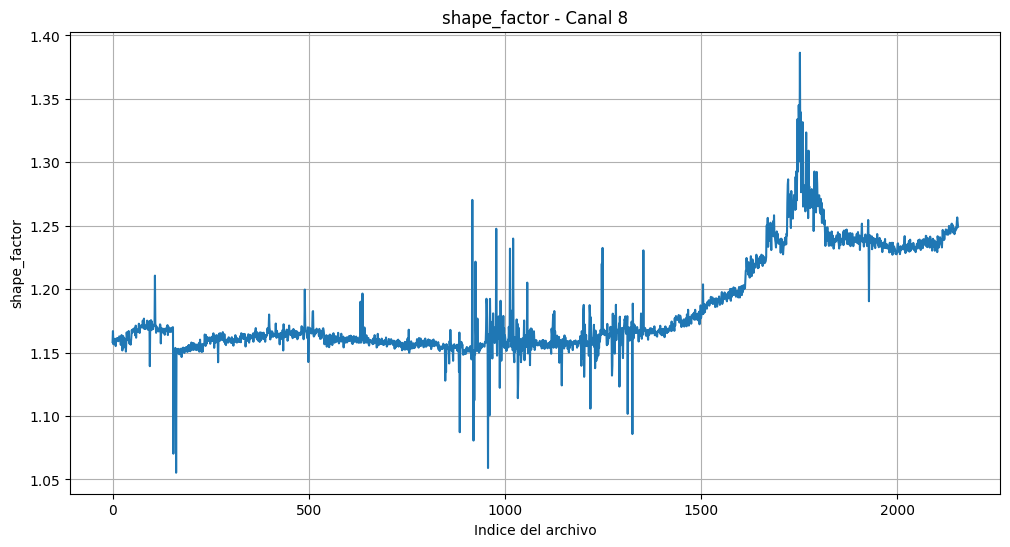

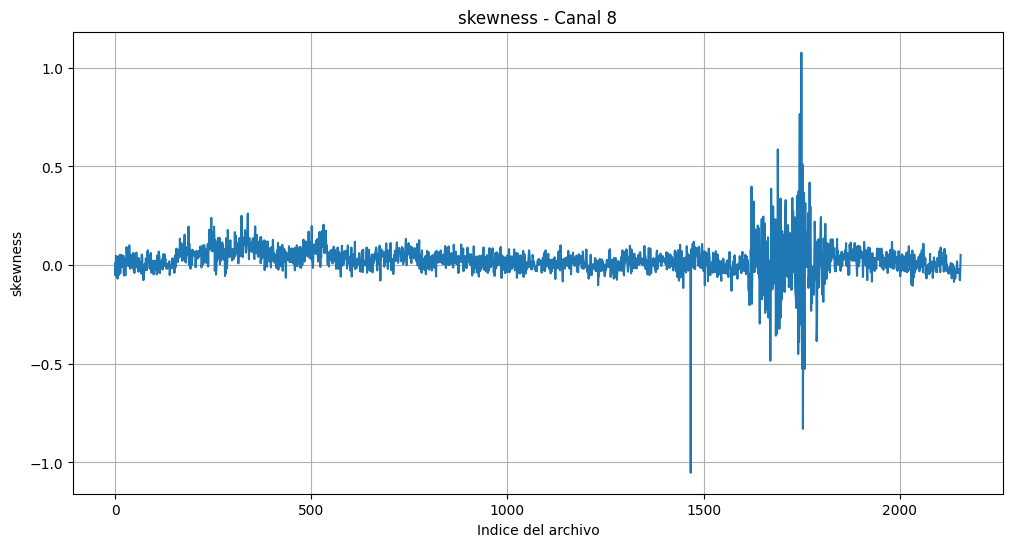

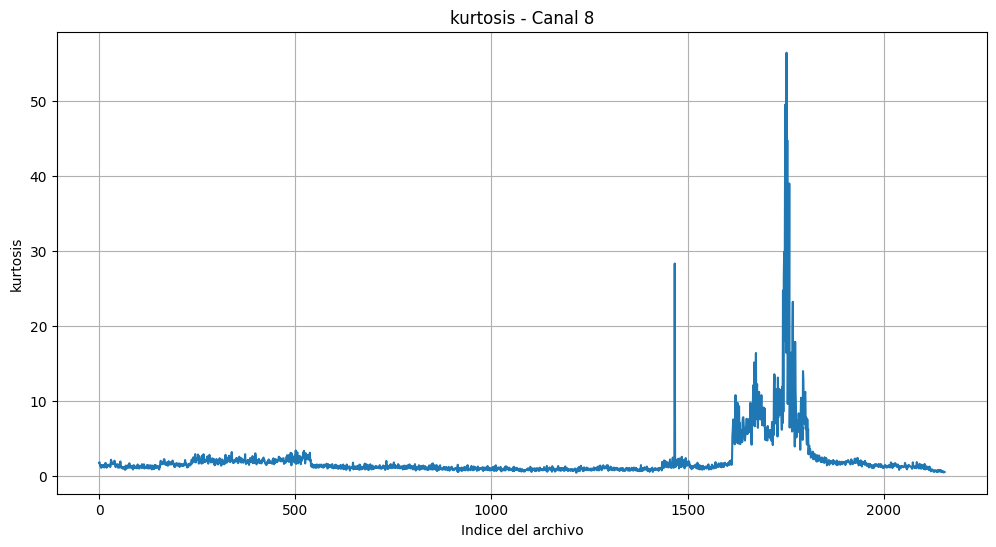

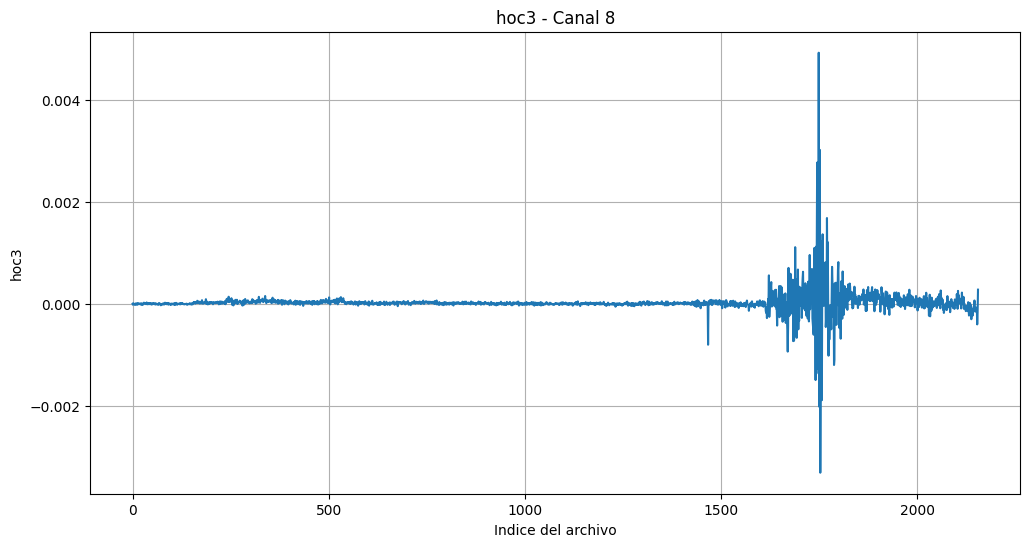

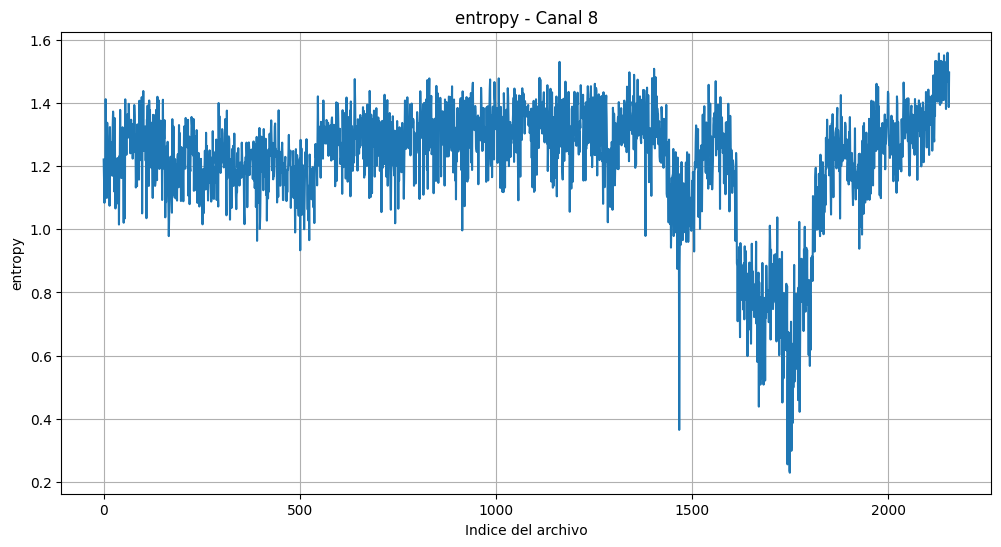

In [45]:
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'mean_amplitude')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'rms_amplitude')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'peak_to_peak_amplitude')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'crest_factor')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'variance')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'standard_deviation')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'standard_error')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'zero_crossings')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'wavelength')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'willison_amplitude')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'slope_sign_change')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'impulse_factor')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'margin_factor')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'shape_factor')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'skewness')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'kurtosis')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'hoc3')
mostrar_grafica(df_agregado_1st_test, 'Canal 8', 'entropy')

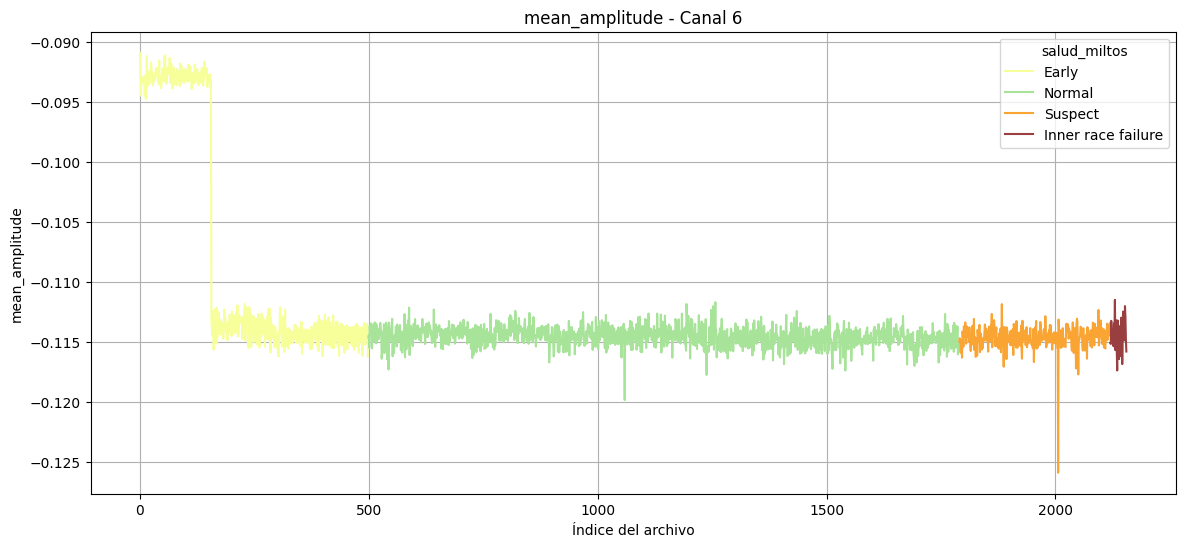

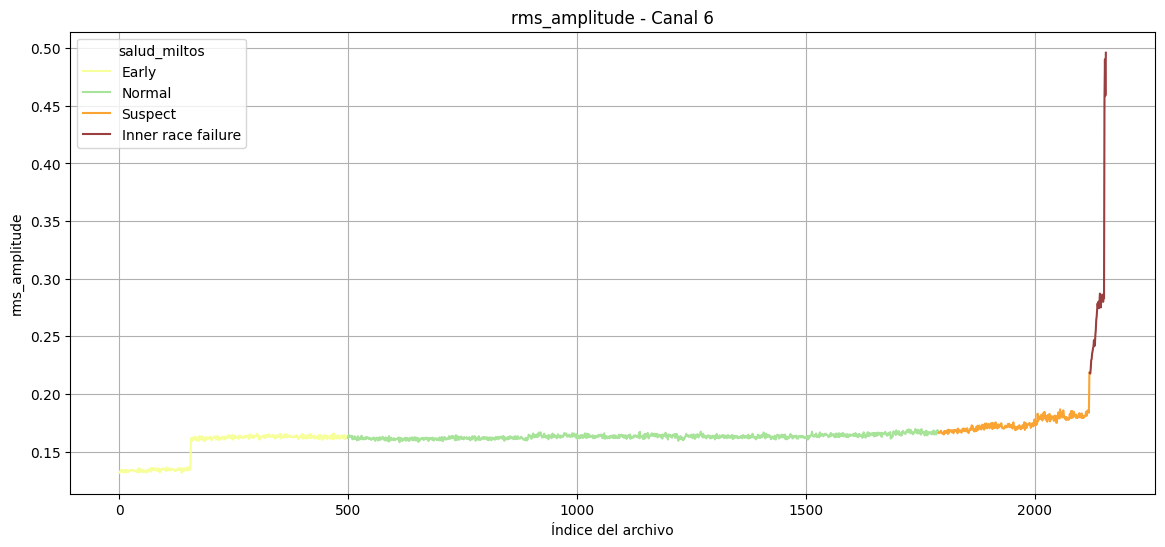

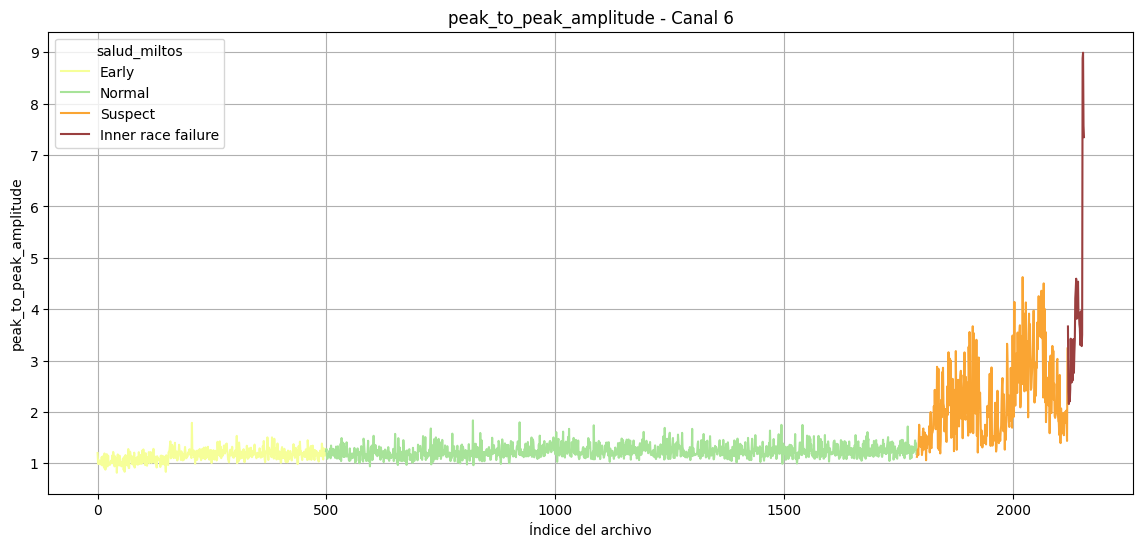

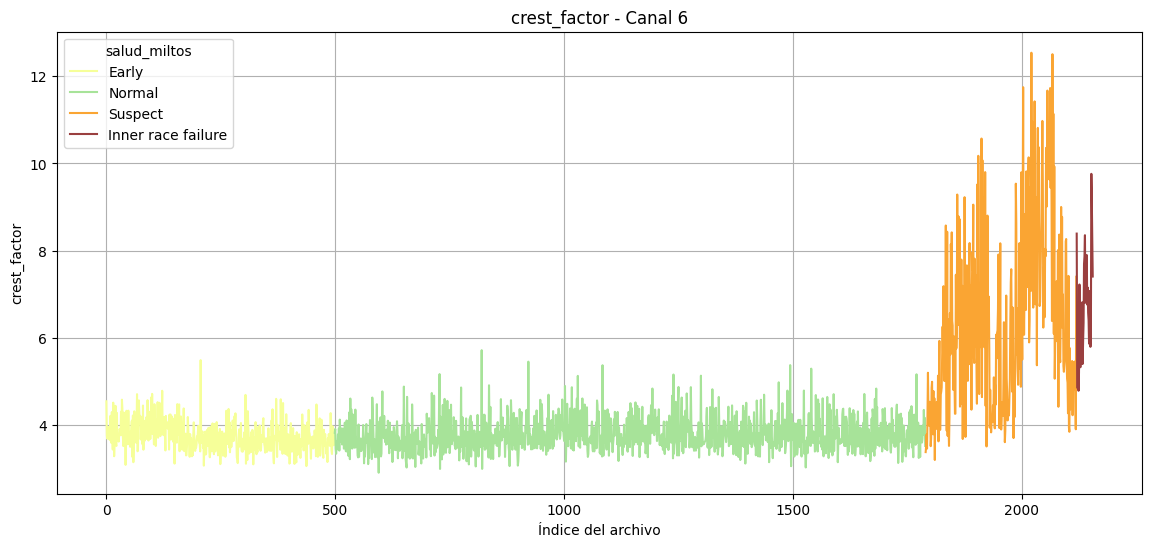

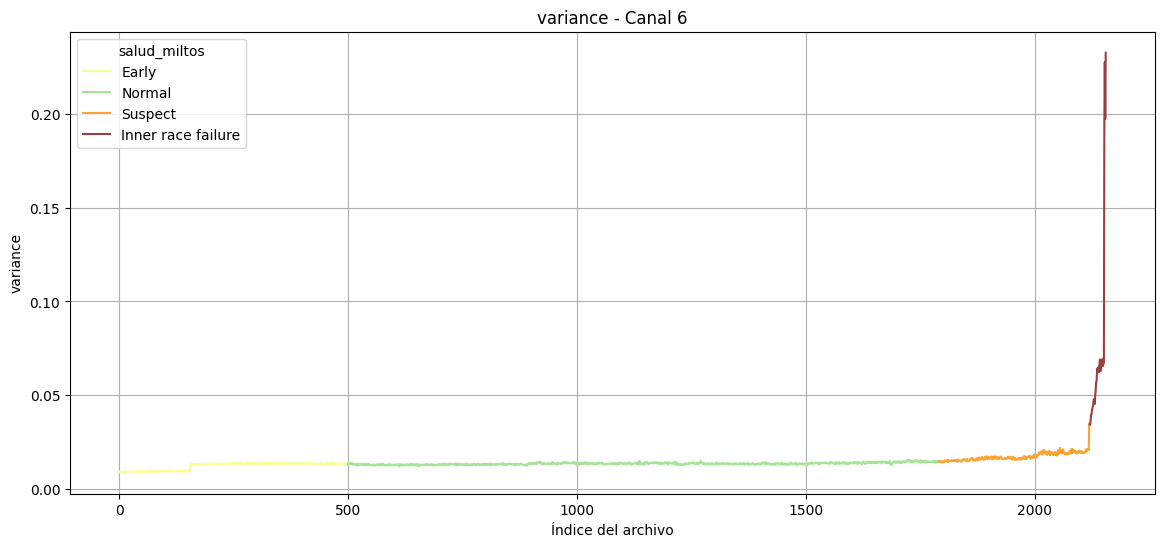

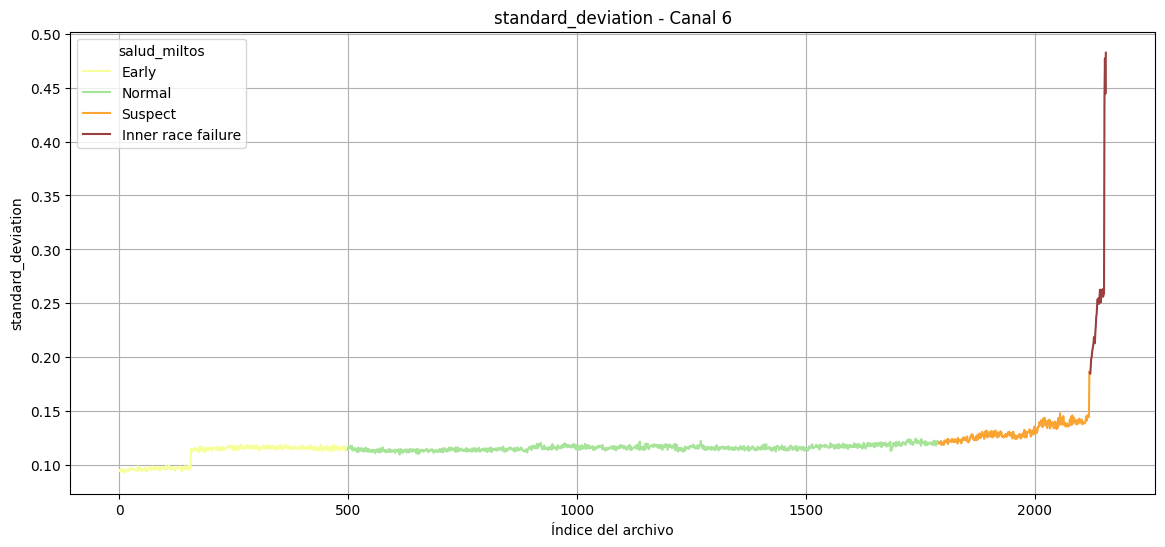

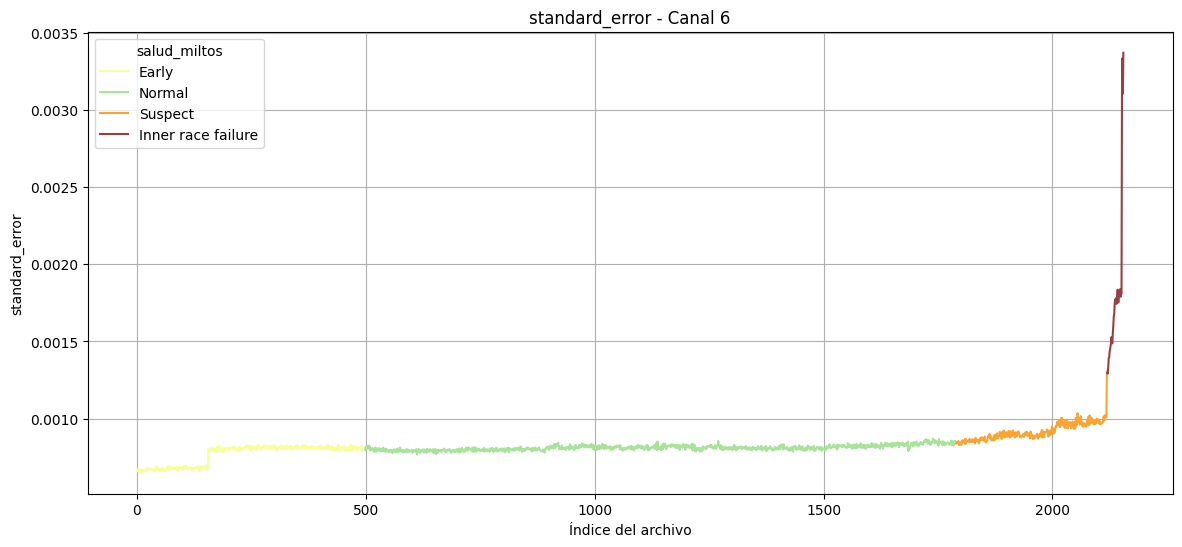

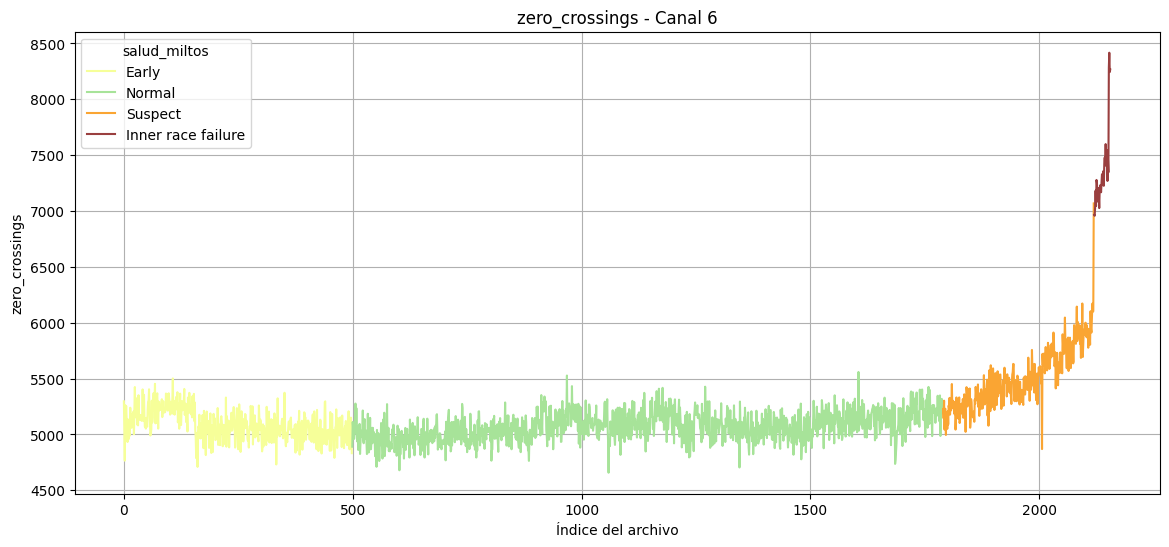

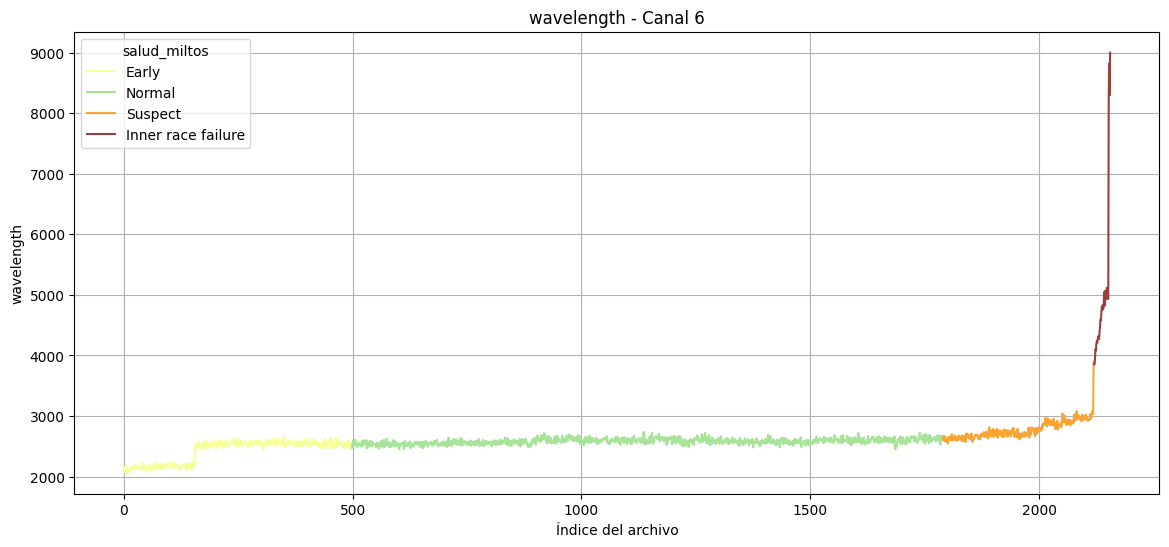

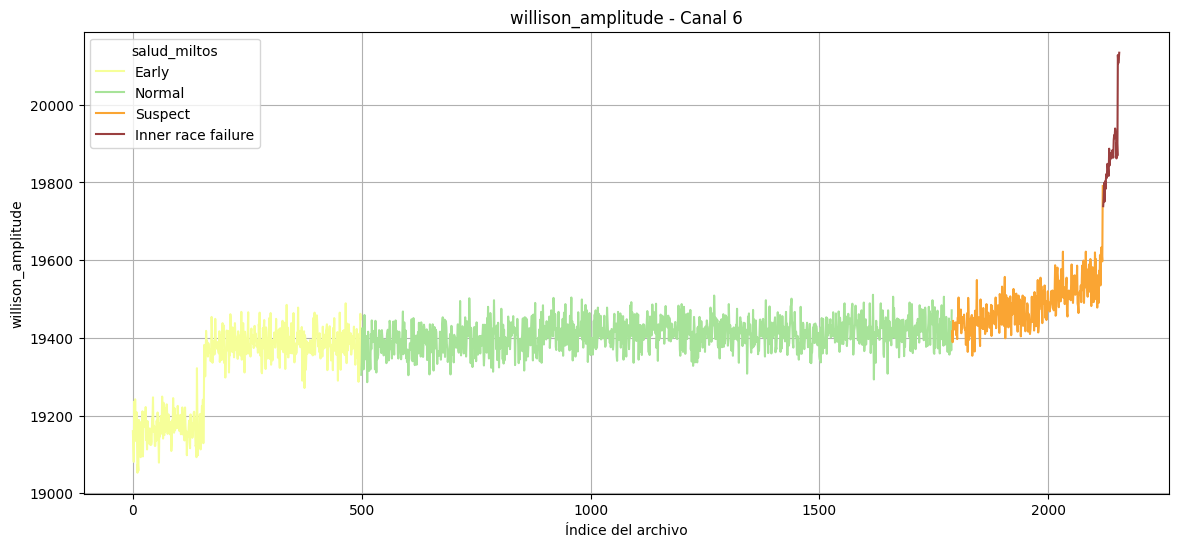

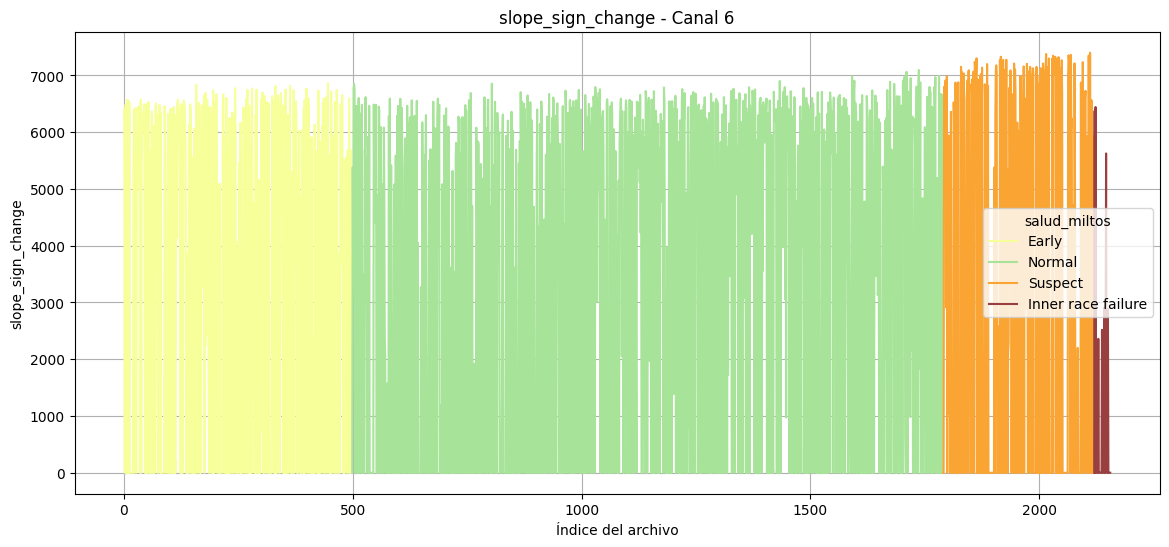

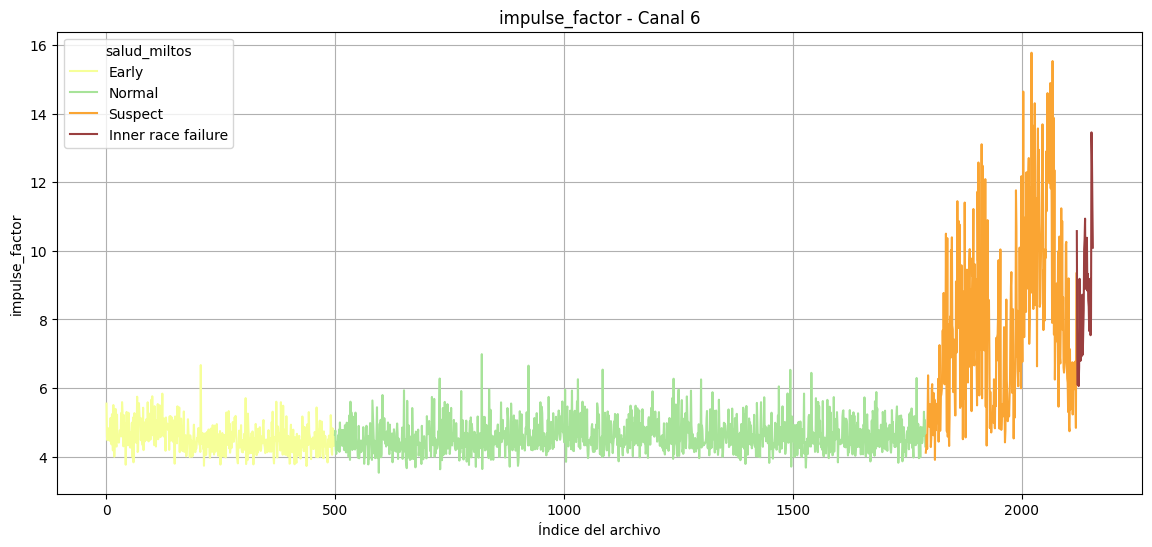

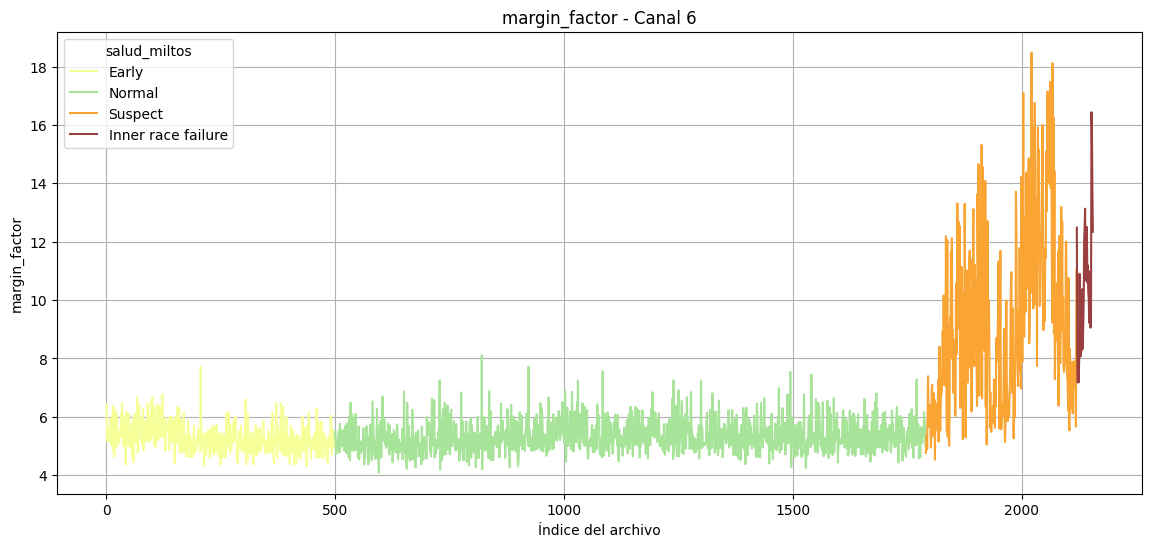

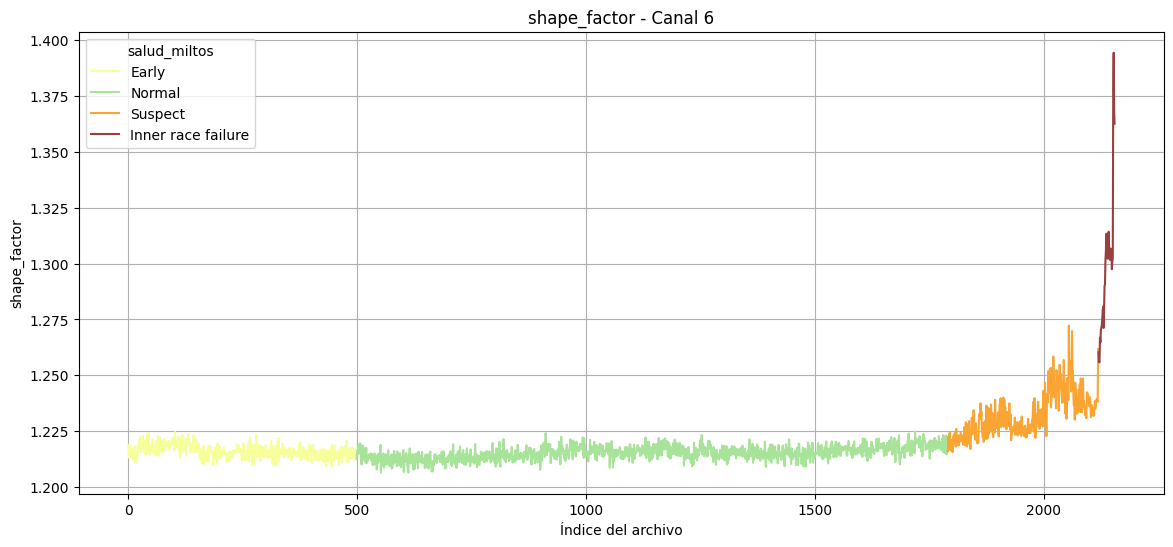

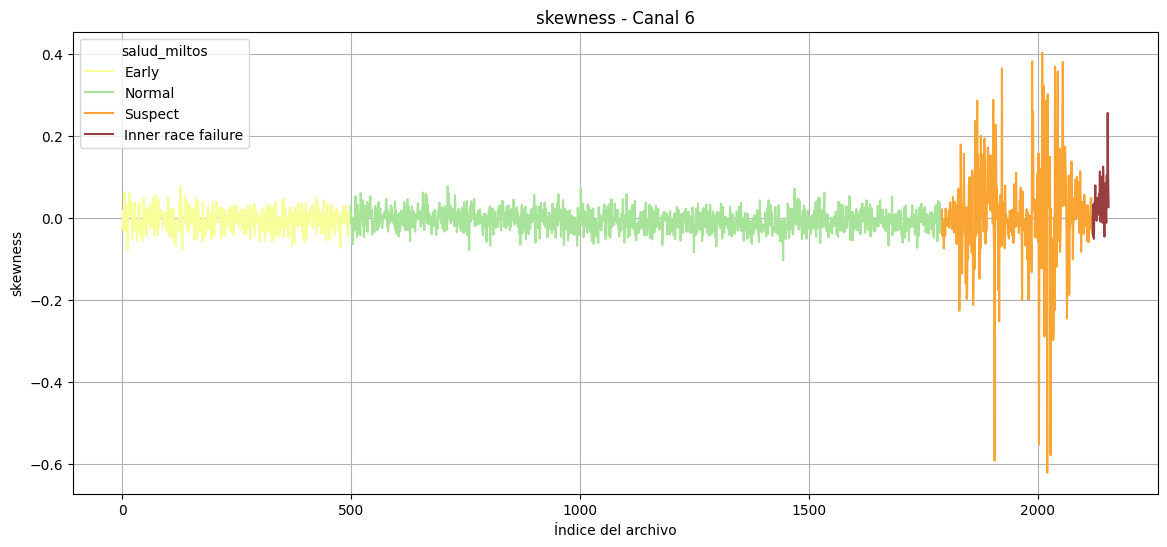

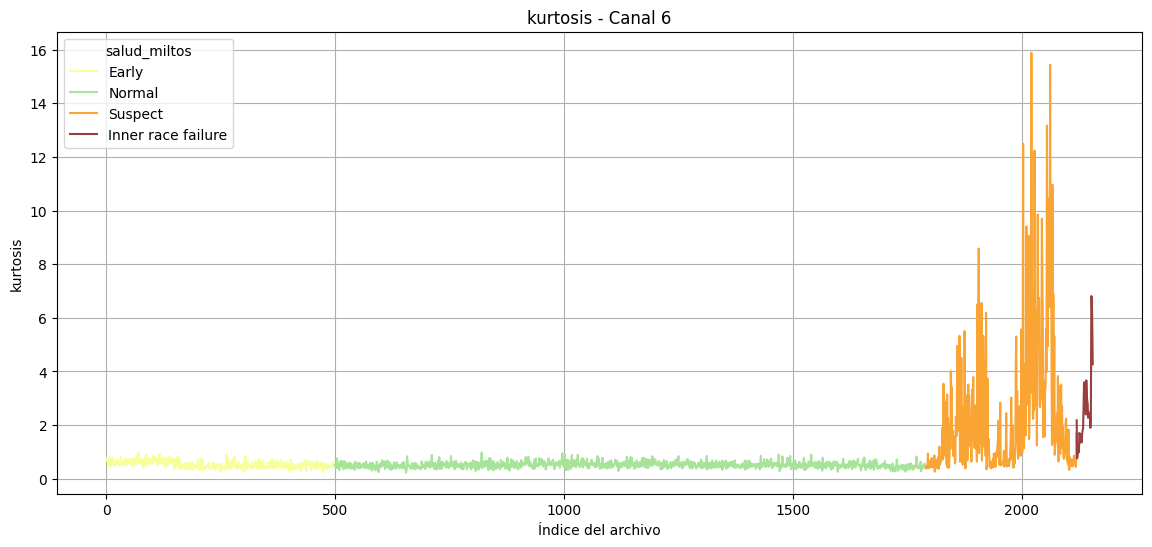

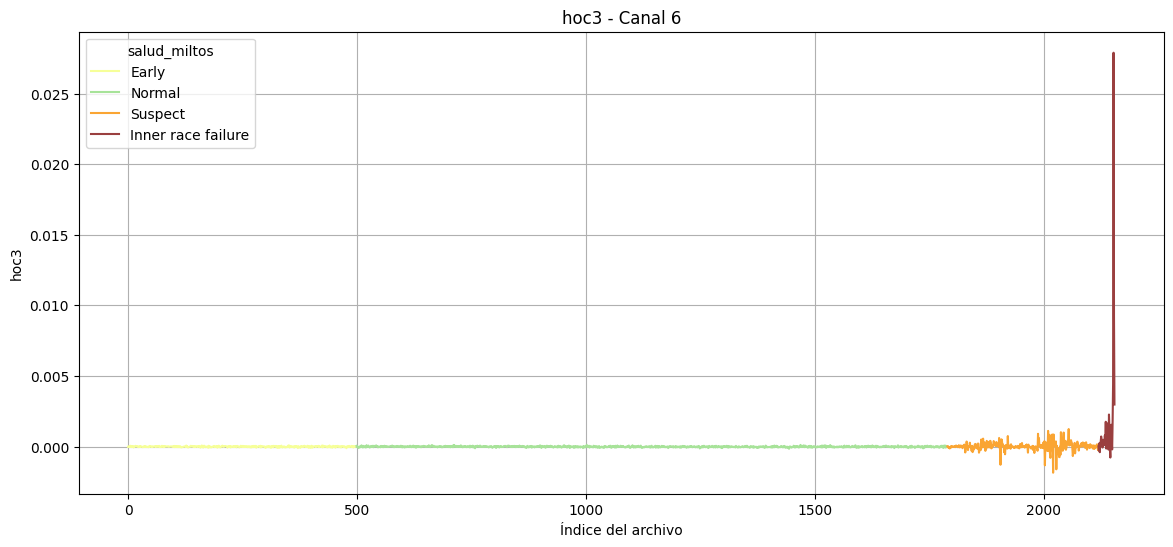

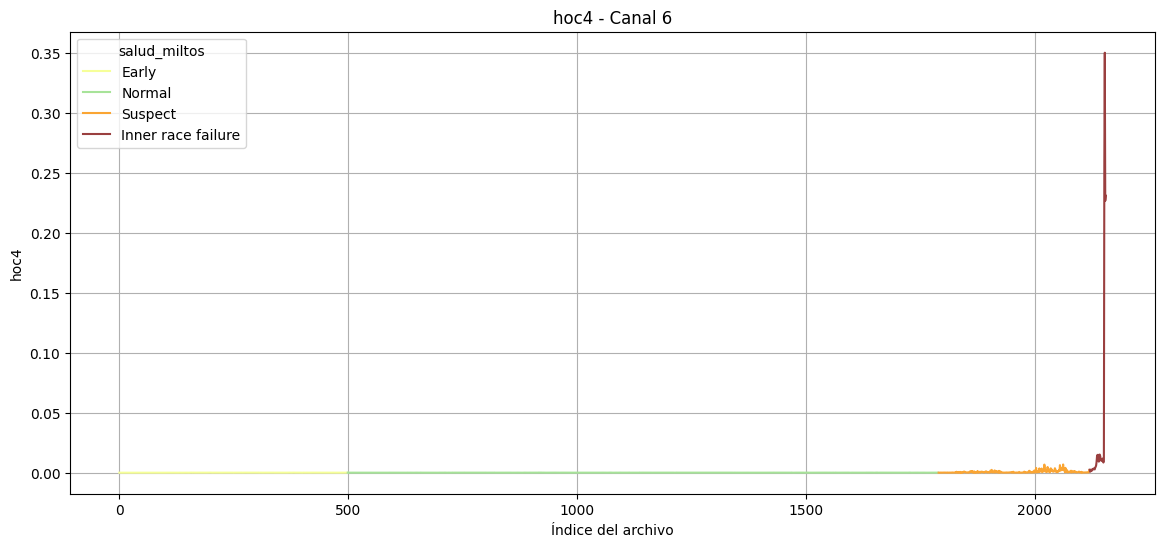

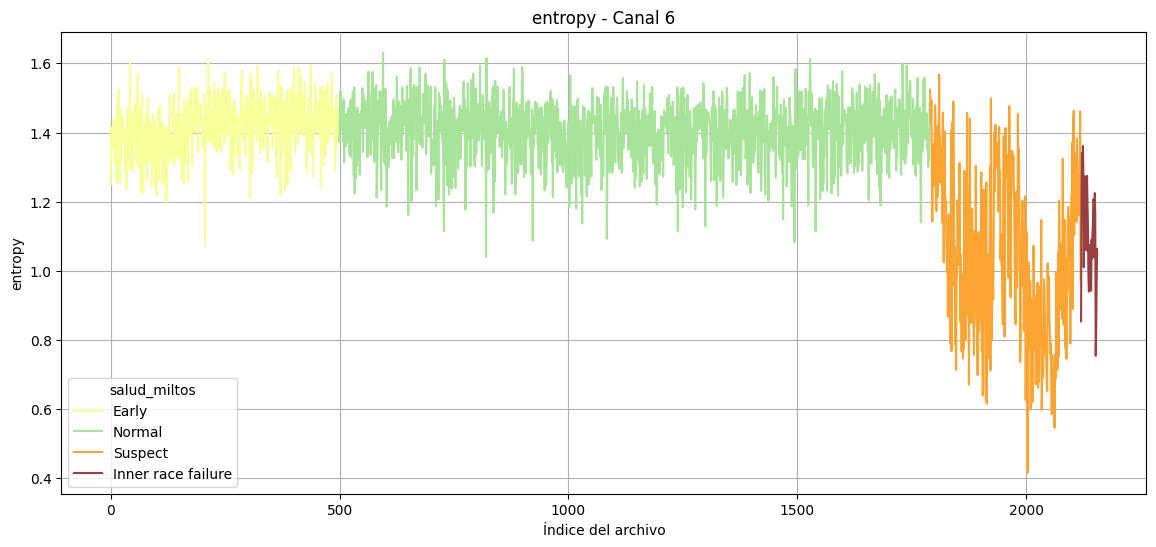

In [ ]:
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'mean_amplitude', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'rms_amplitude', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'peak_to_peak_amplitude', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'crest_factor', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'variance', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'standard_deviation', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'standard_error', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'zero_crossings', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'wavelength', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'willison_amplitude', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'slope_sign_change', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'impulse_factor', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'margin_factor', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'shape_factor', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'skewness', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'kurtosis', 'salud_miltos', colores_salud_hex)
# hoc1 es la media de la serie de tiempo
# hoc2 es la varianza de la serie de tiempo
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'hoc3', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'hoc4', 'salud_miltos', colores_salud_hex)
mostrar_grafica_target(df_agregado_1st_test, 'Canal 6', 'entropy', 'salud_miltos', colores_salud_hex)

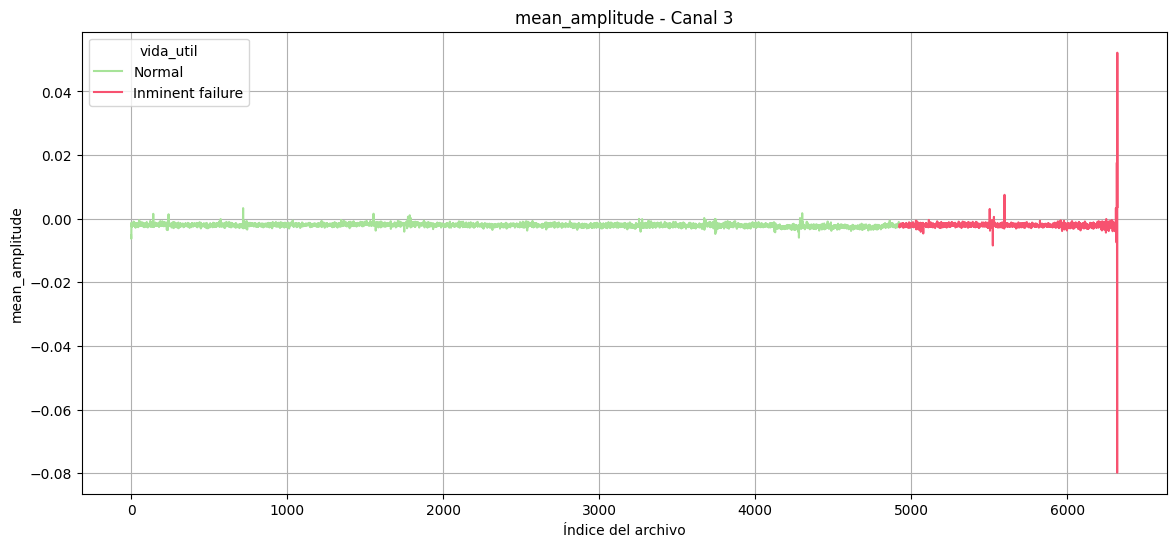

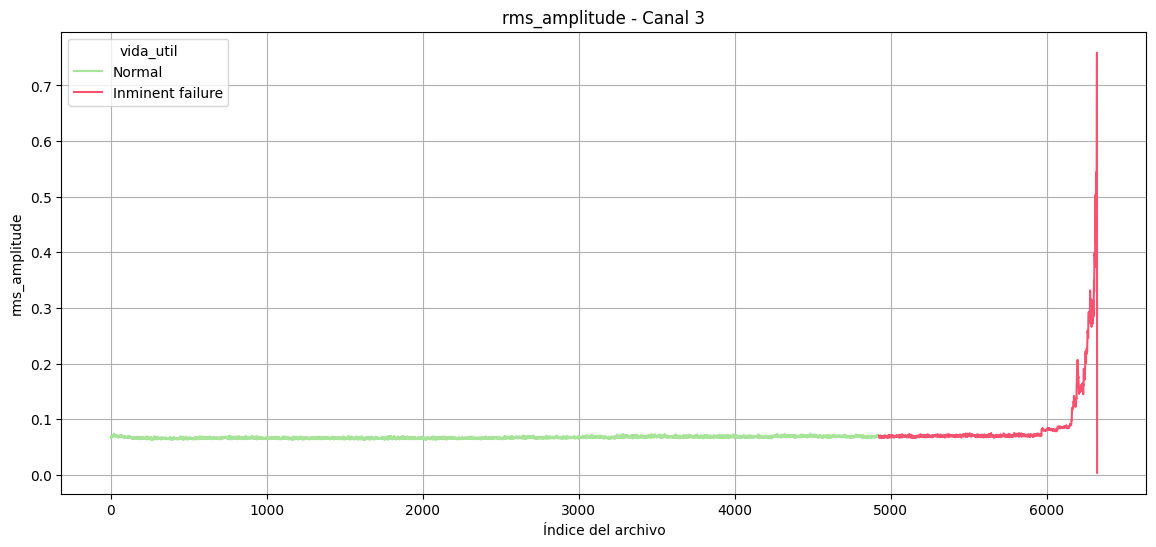

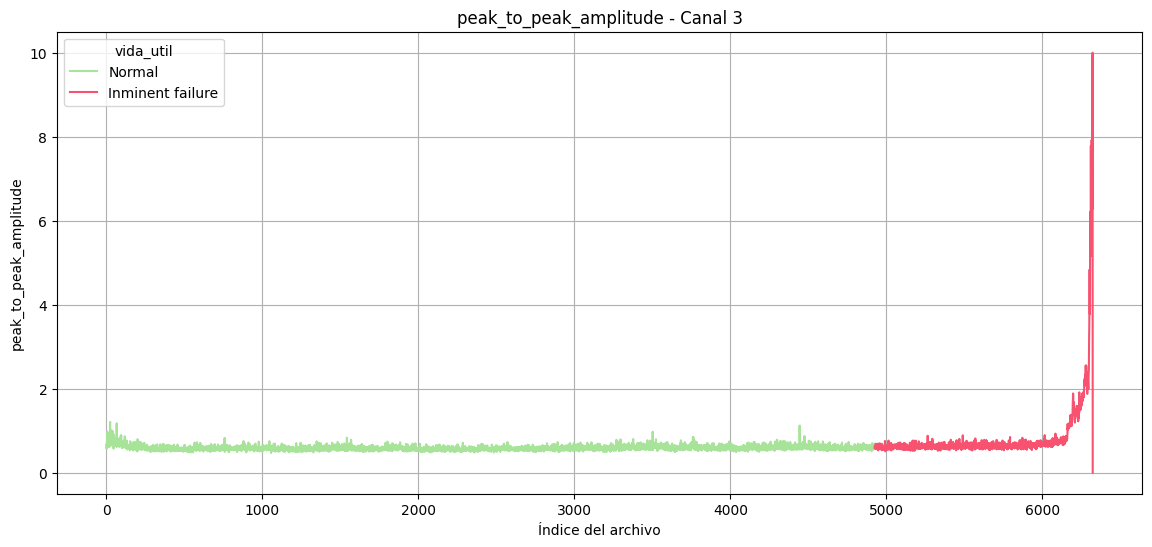

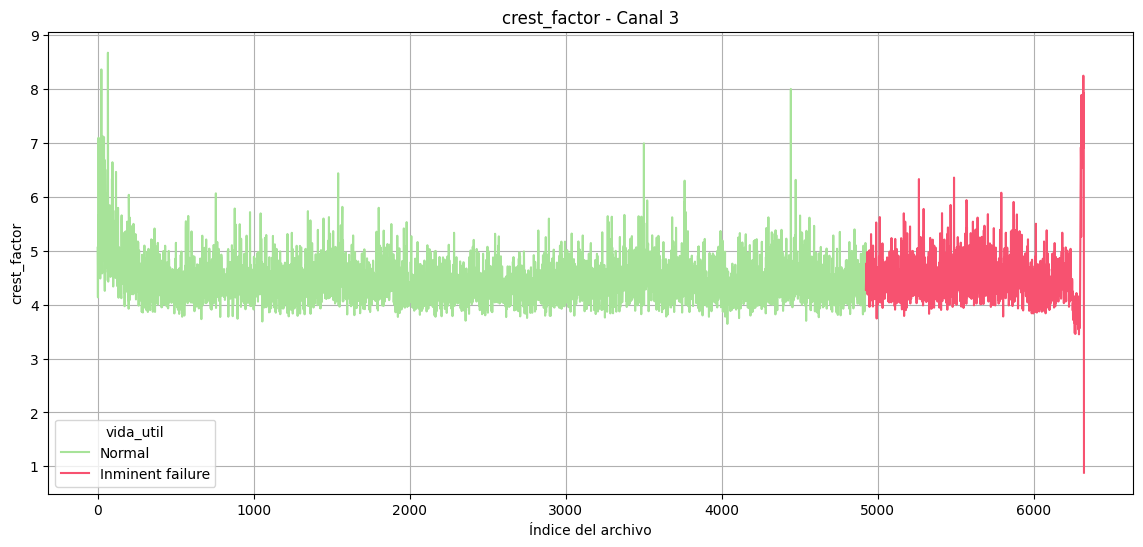

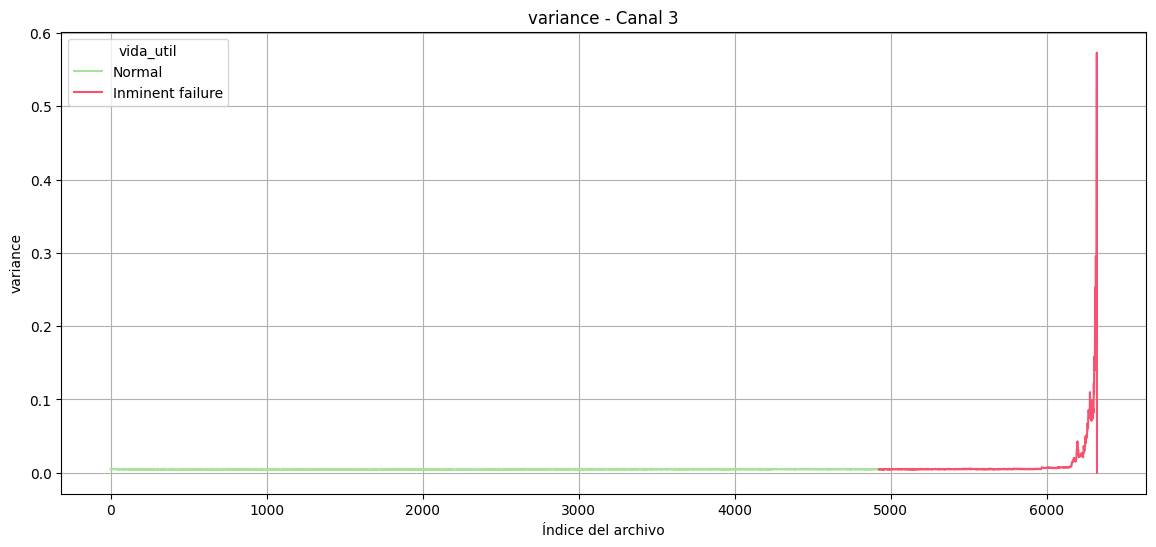

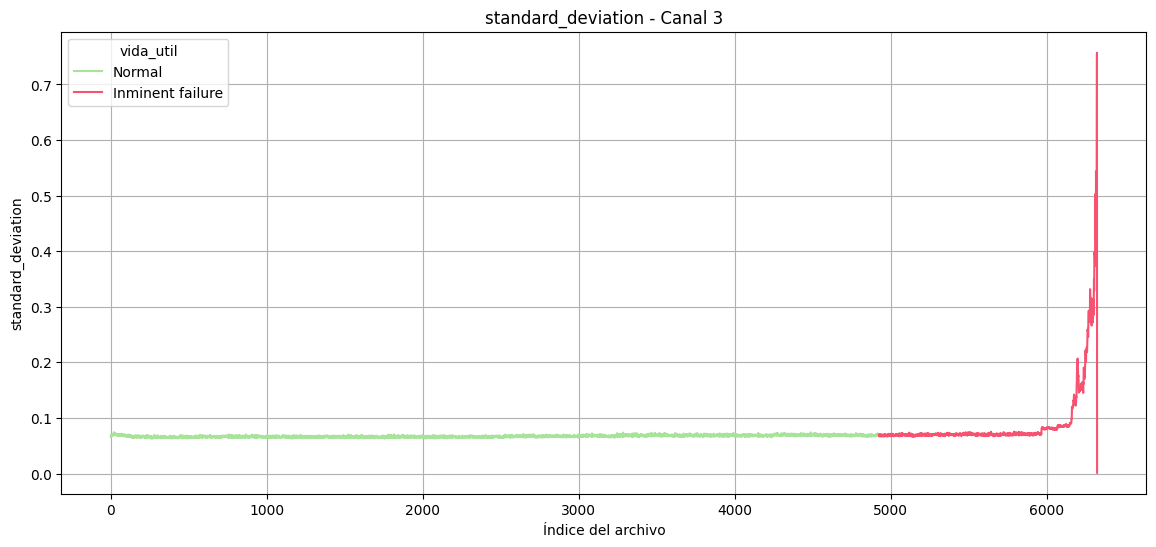

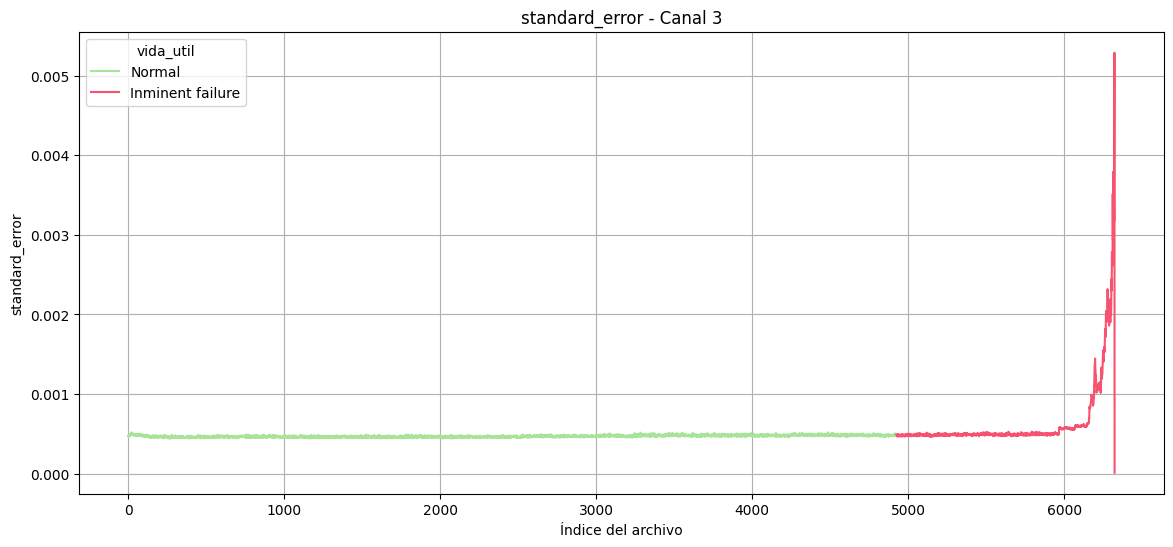

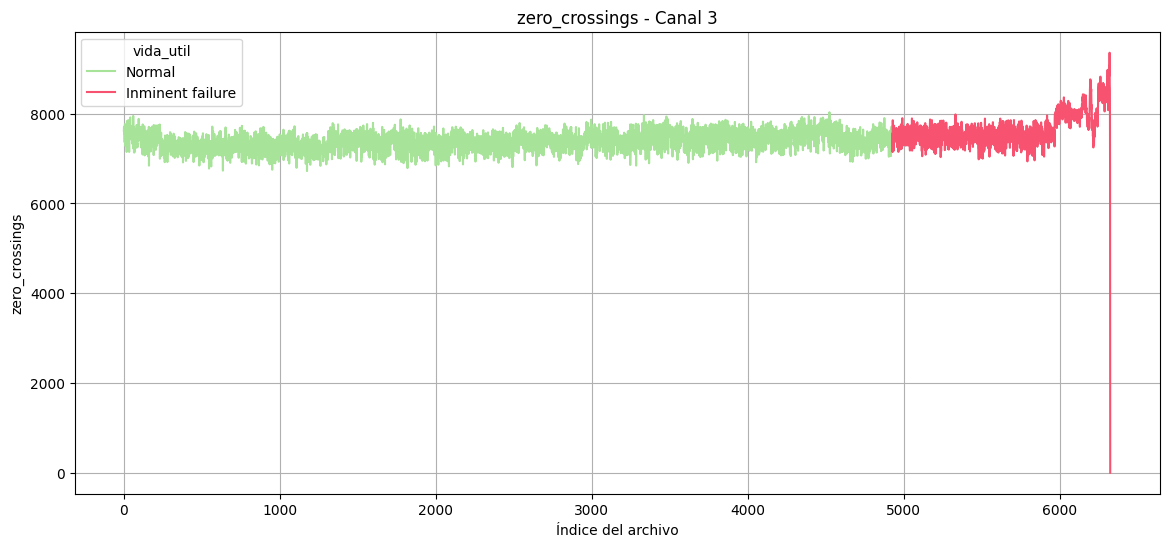

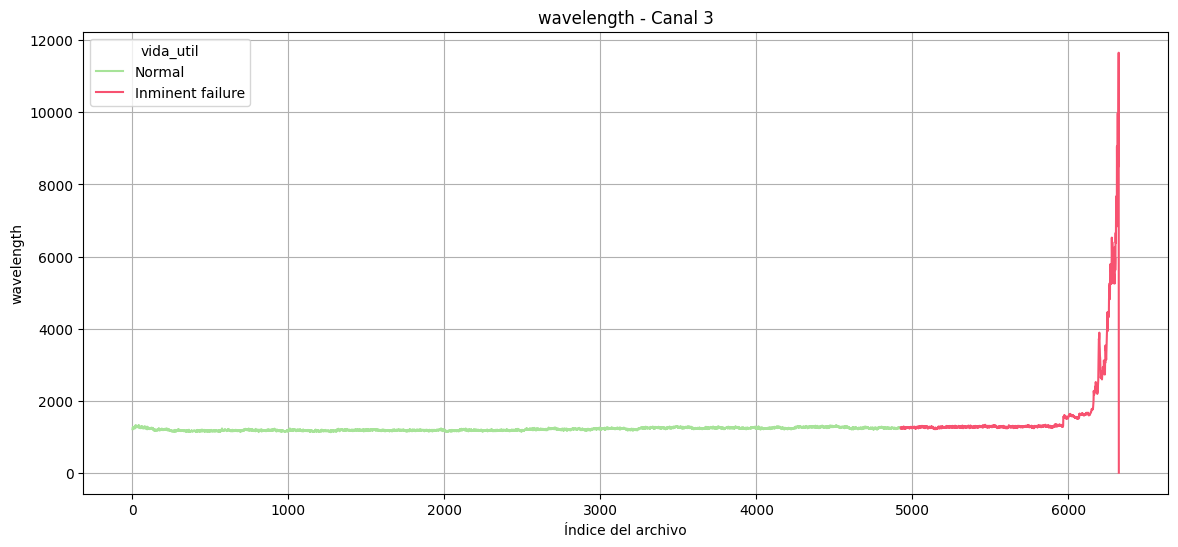

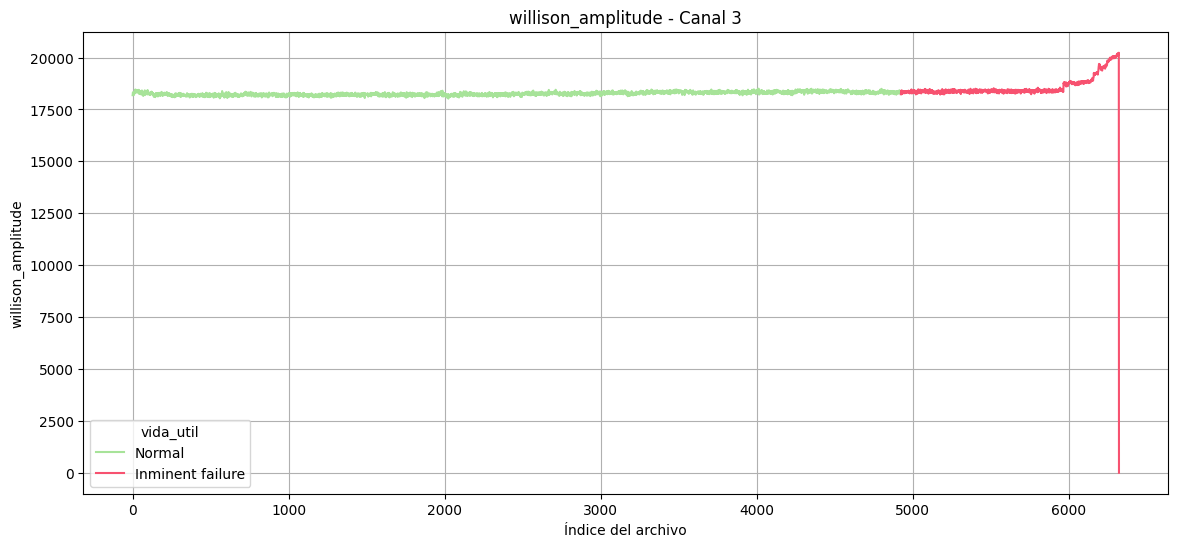

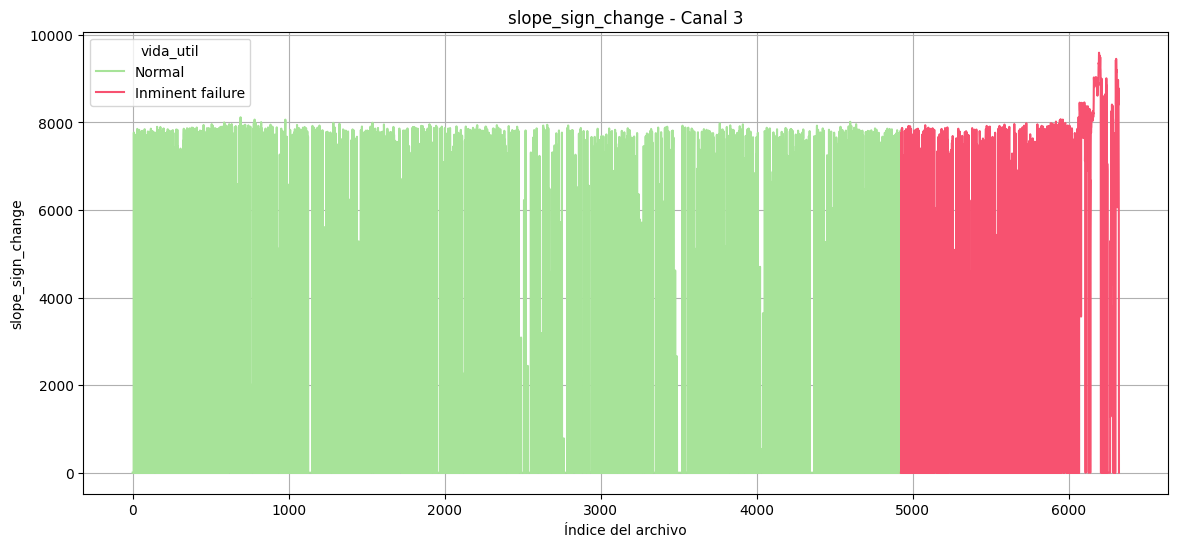

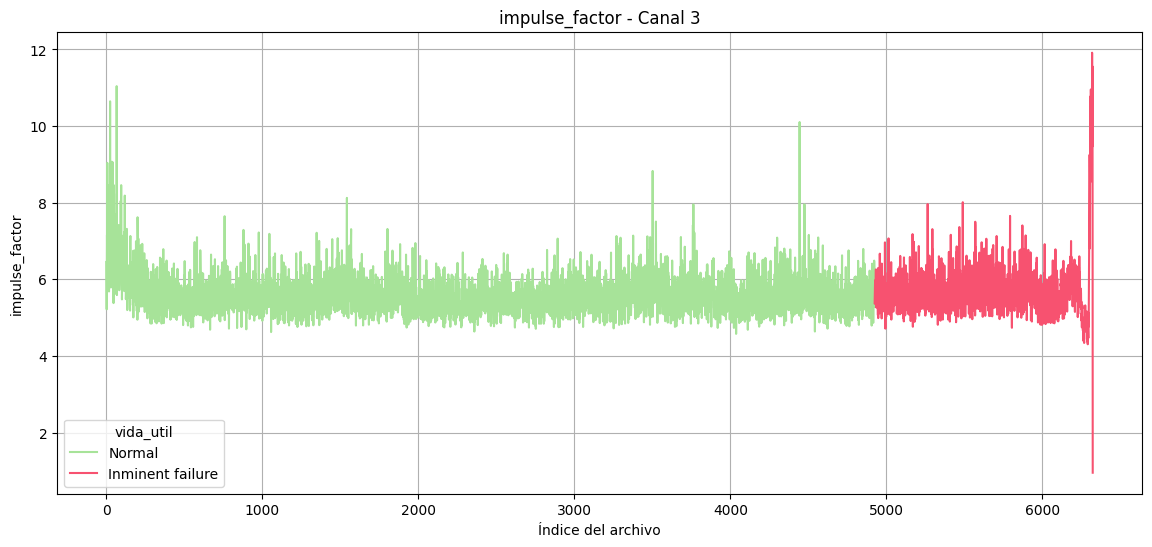

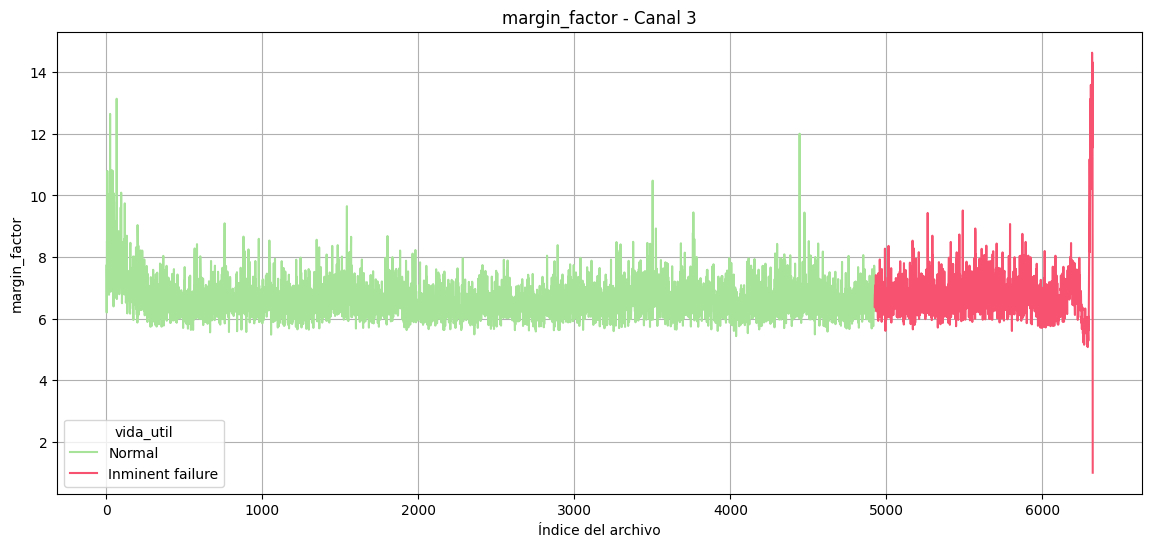

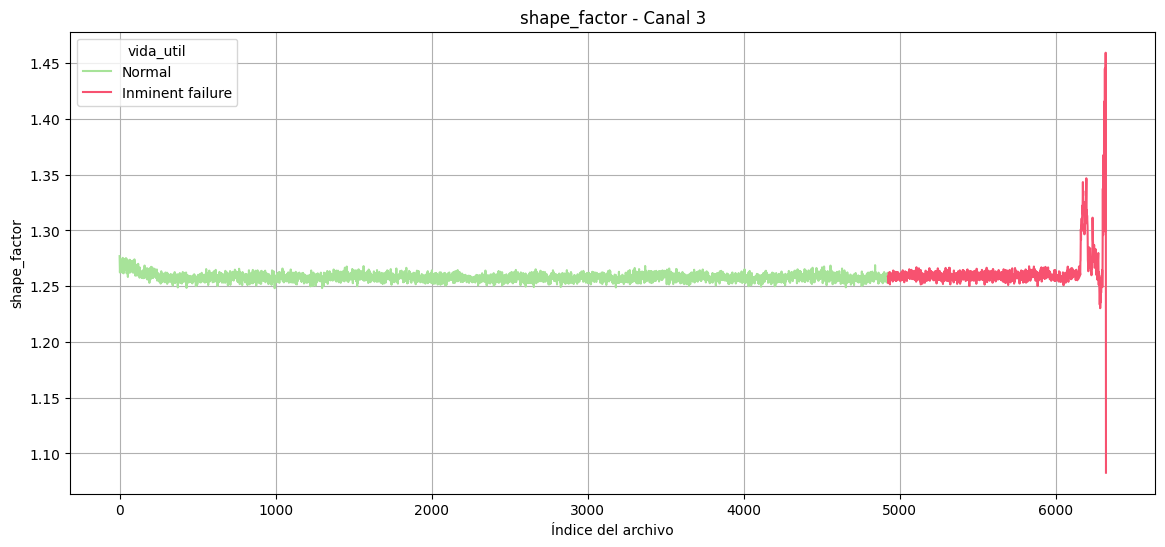

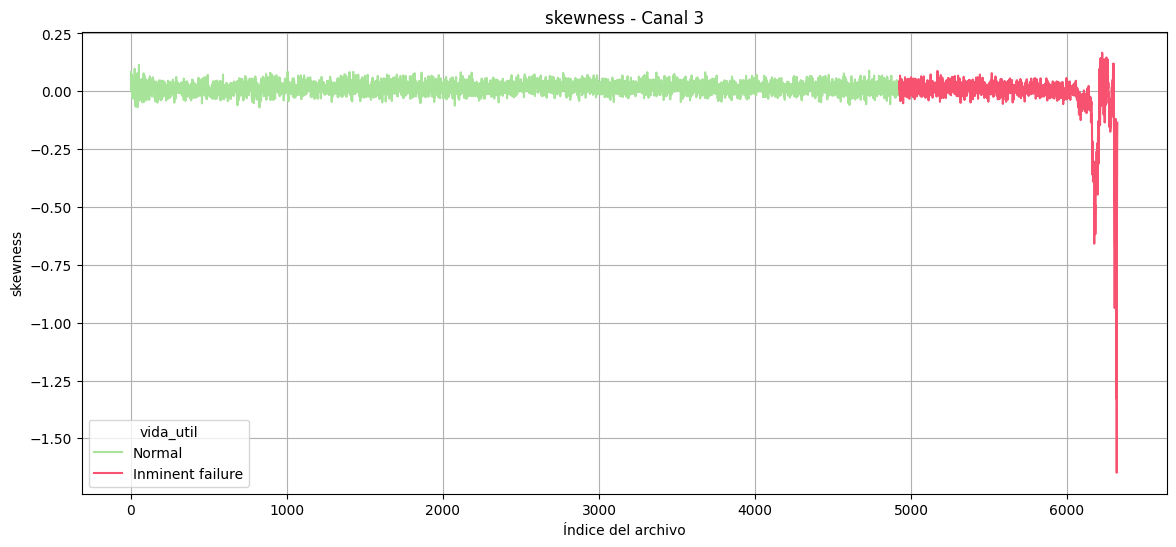

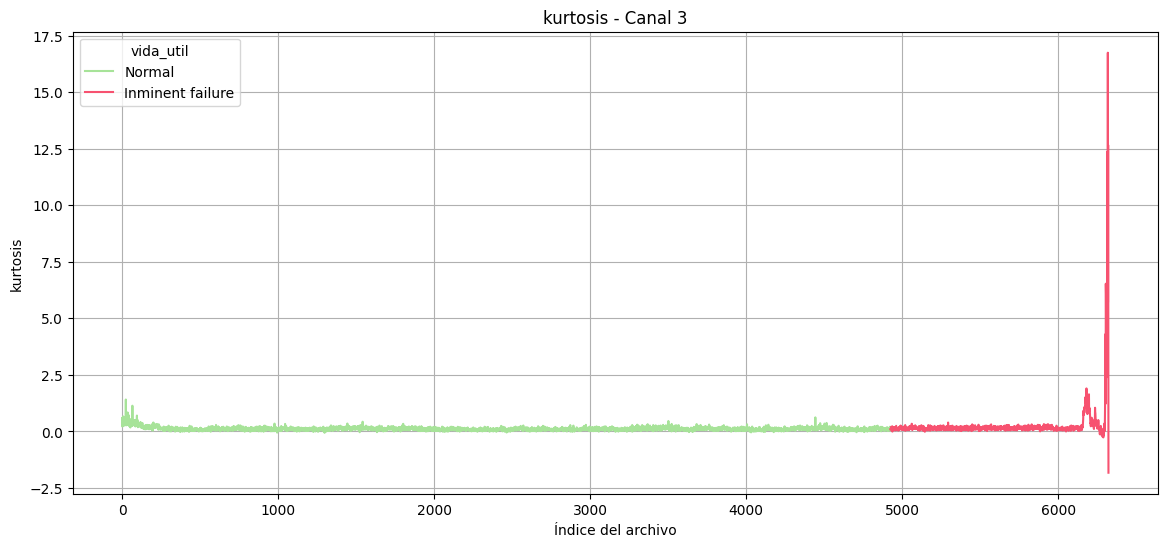

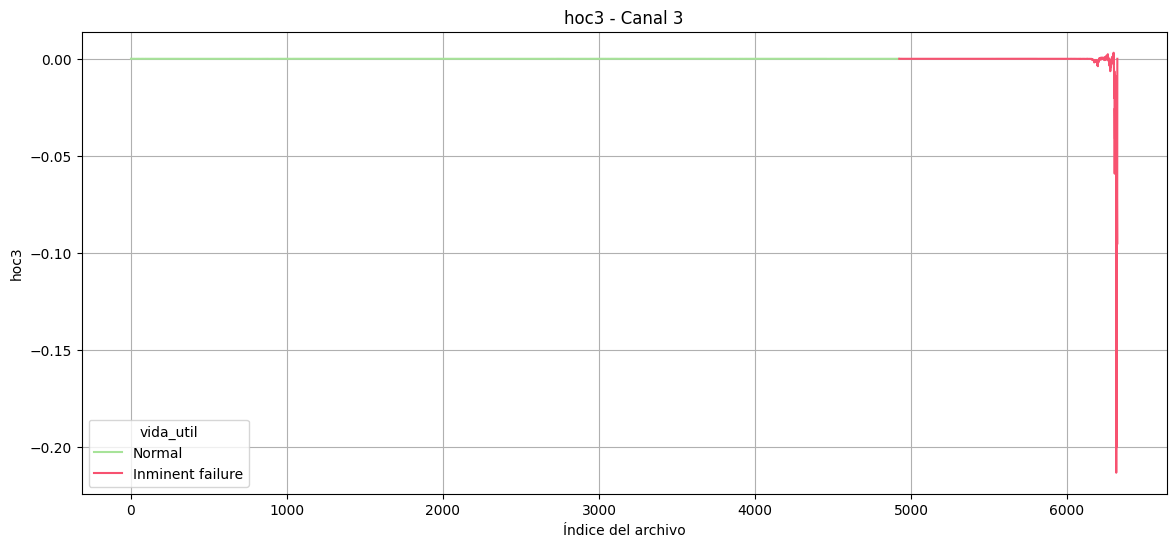

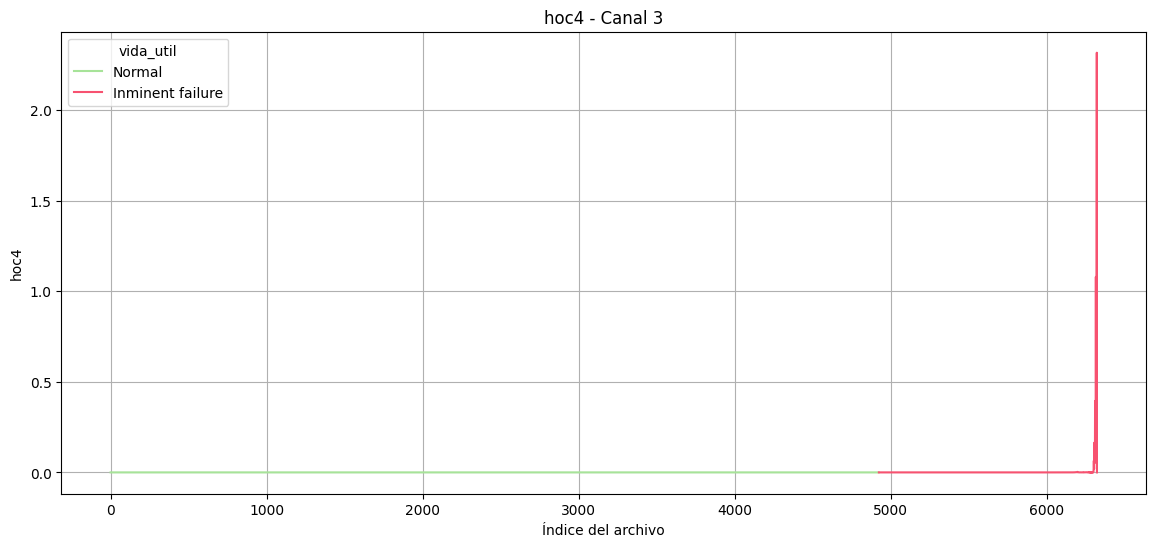

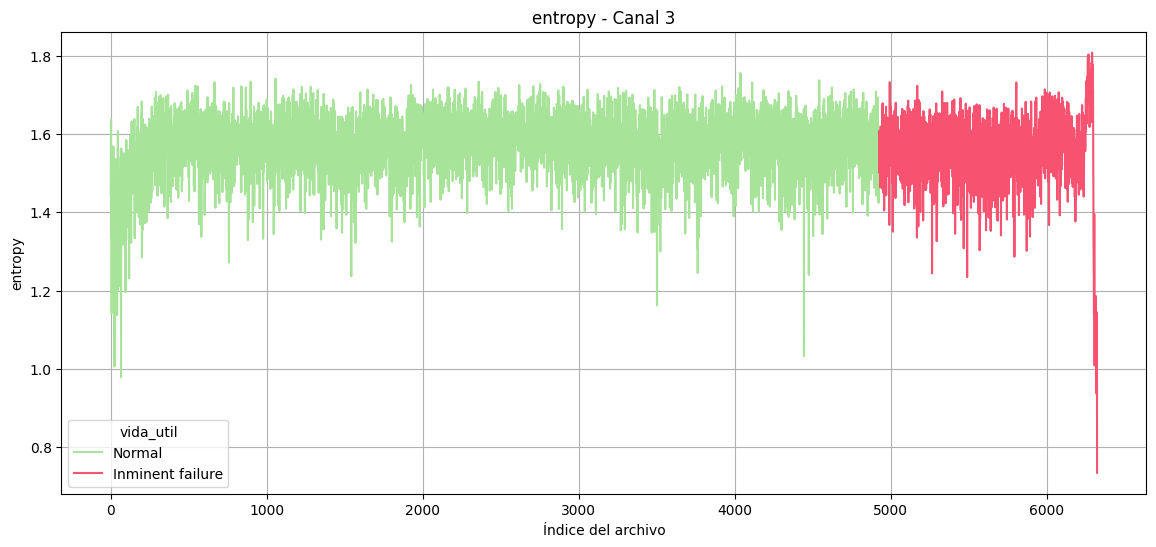

In [59]:
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'mean_amplitude', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'rms_amplitude', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'peak_to_peak_amplitude', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'crest_factor', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'variance', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'standard_deviation', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'standard_error', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'zero_crossings', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'wavelength', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'willison_amplitude', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'slope_sign_change', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'impulse_factor', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'margin_factor', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'shape_factor', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'skewness', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'kurtosis', 'vida_util', colores_salud_hex)
# hoc1 es la media de la serie de tiempo
# hoc2 es la varianza de la serie de tiempo
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'hoc3', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'hoc4', 'vida_util', colores_salud_hex)
mostrar_grafica_target(df_agregado_3rd_test, 'Canal 3', 'entropy', 'vida_util', colores_salud_hex)